In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.preprocessing import MinMaxScaler

# Evaluation Library
import math
from sklearn import metrics as ms

stk = pd.read_csv("D:\coding\ML_assignment\stock_data.csv")

stock = stk.copy()

In [2]:
# Printing The Start Date And End Date Of The Dataset
sd = stock.iloc[0,0]
ed = stock.iloc[-1,0]

print('Starting Date',sd)
print('Ending Date',ed)

Starting Date 2/1/2013
Ending Date 25/10/2024


In [2]:
stock = pd.read_csv('D:\coding\ML_assignment\After_preprocess.csv')

print(stock.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2926 entries, 0 to 2925
Data columns (total 22 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   time        2926 non-null   object 
 1   open        2926 non-null   float64
 2   high        2926 non-null   float64
 3   low         2926 non-null   float64
 4   close       2926 non-null   float64
 5   Volume      2926 non-null   float64
 6   RSI         2926 non-null   float64
 7   Short MA 9  2926 non-null   float64
 8   Long MA 21  2926 non-null   float64
 9   MA 50       2926 non-null   float64
 10  MA 20       2926 non-null   float64
 11  MA 10       2926 non-null   float64
 12  EMA 10      2926 non-null   float64
 13  EMA 20      2926 non-null   float64
 14  EMA 50      2926 non-null   float64
 15  STD         2926 non-null   float64
 16  Trends      2926 non-null   float64
 17  %K          2926 non-null   float64
 18  %D          2926 non-null   float64
 19  ATR         2926 non-null  

# Data Calculation

RSI (Relative Strength Index)

RSI: A popular technical indicator in stock market analysis used to measure the speed and magnitude of recent price changes.

In [4]:
# Set Window Length
window_length = 14

# Calculate Price Change (Delta)
delta = stock['close'].diff(1)
stock['delta'] = delta

# Calculate Gains and Losses
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

# Compute Moving Averages
avg_gain = gain.rolling(window = window_length, min_periods = 1).mean()
avg_loss = loss.rolling(window = window_length, min_periods = 1).mean()

# Calculate Relative Strength (RS)
# Note that RS is the ratio of average gains to average losses.
rs = avg_gain / avg_loss

# Calculate RSI
stock['RSI'] = 100 - (100/(1+rs))      

""" 
    The RSI value ranges from 0 to 100:
        Above 70: Overbought condition (potential sell signal).
        Below 30: Oversold condition (potential buy signal).
"""

stock = stock.drop(columns=['delta'])
display(stock.head(50))

# window_length: This defines the period (14 days) used to calculate the moving average of gains and losses, which is the standard for RSI.
# .diff(1): computes the difference between the current and previous row in the close column (daily price change).

# gain: Keeps positive price changes and replaces negative changes with 0.
# loss: Converts negative price changes to positive (absolute values) and replaces positive changes with 0.

# rolling(window = window_length).mean(): Calculates a rolling (moving) average over 14 days for both gain and loss.
# min_periods = 1: Ensures that the moving average is calculated even if there are fewer than 14 data points (useful for initial rows).


,time,open,high,low,close,Volume,RSI
0,2/1/2013,2.333331,2.363325,2.313664,2.357331,17920667,NaN
1,3/1/2013,2.345330,2.363331,2.316664,2.317998,11129126,0.000000
2,4/1/2013,2.319998,2.319998,2.261331,2.293330,10109905,0.000000
3,7/1/2013,2.319998,2.319998,2.259997,2.289331,6628641,0.000000
4,8/1/2013,2.299998,2.299998,2.207331,2.245330,19259794,0.000000
5,9/1/2013,2.267330,2.279331,2.226664,2.242664,10469695,0.000000
6,10/1/2013,2.257998,2.265998,2.225331,2.235331,13836088,0.000000
7,11/1/2013,2.269330,2.269330,2.140665,2.193998,23449133,0.000000
8,14/1/2013,2.205331,2.225331,2.189998,2.217330,13875283,12.499397
9,15/1/2013,2.207331,2.283331,2.205331,2.259997,24365859,28.778801


MA (Moving Average)

In [5]:
# Simple Moving Averages (SMA)
# Note that SMA is the unweighted average of the closing prices over a specified period.
stock['Short MA 9'] = stock['close'].rolling(window = 9).mean()
stock['Long MA 21'] = stock['close'].rolling(window = 21).mean()
stock['MA 50'] = stock['close'].rolling(window = 50).mean()
stock['MA 20'] = stock['close'].rolling(window = 20).mean()
stock['MA 10'] = stock['close'].rolling(window = 10).mean()

# Exponential Moving Averages (EMA)
# Note that EMA is a weighted moving average that gives more weight to recent prices, making it more responsive to recent price changes compared to the SMA.
n = 10
alpha = 2 / (n + 1)
stock['EMA 10'] = stock['close'].ewm(span = n, adjust = False).mean()

n = 20
alpha = 2 / (n + 1)
stock['EMA 20'] = stock['close'].ewm(span = n, adjust = False).mean()

n=50
alpha = 2 / (n + 1)
stock['EMA 50'] = stock['close'].ewm(span = n, adjust = False).mean()

display(stock[['Short MA 9','Long MA 21','EMA 50','MA 50','EMA 20','MA 20','EMA 10','MA 10']].head(20))

# alpha: Smoothing factor.
# .ewm(span = n, adjust = False).mean(): Refers to exponential weighted moving average which computes the EMA using the specified span (number of days).
# adjust = False: Ensures the weights are normalized to sum to 1.

,Short MA 9,Long MA 21,EMA 50,MA 50,EMA 20,MA 20,EMA 10,MA 10
0,NaN,NaN,2.357331,NaN,2.357331,NaN,2.357331,NaN
1,NaN,NaN,2.355789,NaN,2.353585,NaN,2.350180,NaN
2,NaN,NaN,2.353339,NaN,2.347846,NaN,2.339843,NaN
3,NaN,NaN,2.350829,NaN,2.342274,NaN,2.330659,NaN
4,NaN,NaN,2.346692,NaN,2.333041,NaN,2.315145,NaN
5,NaN,NaN,2.342612,NaN,2.324433,NaN,2.301966,NaN
6,NaN,NaN,2.338405,NaN,2.315948,NaN,2.289851,NaN
7,NaN,NaN,2.332742,NaN,2.304333,NaN,2.272423,NaN
8,2.265849,NaN,2.328216,NaN,2.296047,NaN,2.262406,NaN
9,2.255034,NaN,2.325541,NaN,2.292614,NaN,2.261968,2.265264


Trends (Bollinger Bands)

Bollinger Bands: A technical analysis tool for identifying price volatility and potential trends in a stock. It also calculates daily returns and a normalized trend indicator based on the position of the price within the Bollinger Bands.

In [6]:
n = 20       
num_std_dev = 2    

stock['Basis'] = stock['MA 20']

stock['STD'] = stock['close'].rolling(window = n).std()

stock['Upper'] = stock['Basis'] + (stock['STD'] * num_std_dev)
stock['Lower'] = stock['Basis'] - (stock['STD'] * num_std_dev)

stock['Daily Return'] = stock['close'].pct_change()
volatility = stock['Daily Return'].std()

stock['Trends'] = ((stock['close'] - stock['Lower']) / (stock['Upper'] - stock['Lower'])) * 100

display(stock[['close','Basis', 'Upper','Lower','Trends']].head(50))

# Reduce Dimensionality
stock = stock.drop(columns=['Daily Return','Basis', 'Upper','Lower'])

,close,Basis,Upper,Lower,Trends
0,2.357331,NaN,NaN,NaN,NaN
1,2.317998,NaN,NaN,NaN,NaN
2,2.293330,NaN,NaN,NaN,NaN
3,2.289331,NaN,NaN,NaN,NaN
4,2.245330,NaN,NaN,NaN,NaN
5,2.242664,NaN,NaN,NaN,NaN
6,2.235331,NaN,NaN,NaN,NaN
7,2.193998,NaN,NaN,NaN,NaN
8,2.217330,NaN,NaN,NaN,NaN
9,2.259997,NaN,NaN,NaN,NaN


Fast Stochastic Oscillator, %K & Slow Stochastic Oscillator, %D

Stochastic Oscillator: A momentum indicator in technical analysis used to compare a stock's closing price to its price range over a specified period, typically 14 days. It also computes the %D line, a smoothed version of %K, for trend analysis.

In [7]:
n = 14 

stock['Lowest_Low'] = stock['low'].rolling(window = n).min()
stock['Highest_High'] = stock['high'].rolling(window = n).max()

stock['%K'] = ((stock['close'] - stock['Lowest_Low']) / (stock['Highest_High'] - stock['Lowest_Low'])) * 100

stock['%D'] = stock['%K'].rolling(window = 3).mean()

#     Note that %D is used as a signal line for crossovers with %K
#     %K crossing above %D: Potential buy signal.
#     %K crossing below %D: Potential sell signal.

stock = stock.drop(columns=['Lowest_Low', 'Highest_High'])

display(stock[['%K','%D']].head(20))

,%K,%D
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
5,NaN,NaN
6,NaN,NaN
7,NaN,NaN
8,NaN,NaN
9,NaN,NaN


ATR (Average True Range)

ATR: A technical analysis indicator that measures market volatility by considering the range of a stock's price movements, including gaps. Higher ATR indicates higher volatility while lower ATR indicates lower volatity or a period of consolidation. 

In [8]:
n = 14  

stock['prev_close'] = stock['close'].shift()

# shift:Shifts the close column down by one row to represent the previous day's closing price.

stock['TR'] = stock[['high', 'low', 'prev_close']].apply(
    lambda row: max(row['high'] - row['low'], 
    abs(row['high'] - row['prev_close']), 
    abs(row['low'] - row['prev_close'])), axis = 1)

# apply: Allow the users to pass a function and apply it on every single value of the Pandas series. 
# lambda:  A small anonymous function.

stock['ATR'] = stock['TR'].rolling(window = n, min_periods=1).mean() 

stock = stock.drop(columns=['TR', 'prev_close'])

display(stock.head(20))

,time,open,high,low,close,Volume,RSI,Short MA 9,Long MA 21,MA 50,MA 20,MA 10,EMA 10,EMA 20,EMA 50,STD,Trends,%K,%D,ATR
0,2/1/2013,2.333331,2.363325,2.313664,2.357331,17920667,NaN,NaN,NaN,NaN,NaN,NaN,2.357331,2.357331,2.357331,NaN,NaN,NaN,NaN,0.049661
1,3/1/2013,2.345330,2.363331,2.316664,2.317998,11129126,0.000000,NaN,NaN,NaN,NaN,NaN,2.350180,2.353585,2.355789,NaN,NaN,NaN,NaN,0.048164
2,4/1/2013,2.319998,2.319998,2.261331,2.293330,10109905,0.000000,NaN,NaN,NaN,NaN,NaN,2.339843,2.347846,2.353339,NaN,NaN,NaN,NaN,0.051665
3,7/1/2013,2.319998,2.319998,2.259997,2.289331,6628641,0.000000,NaN,NaN,NaN,NaN,NaN,2.330659,2.342274,2.350829,NaN,NaN,NaN,NaN,0.053749
4,8/1/2013,2.299998,2.299998,2.207331,2.245330,19259794,0.000000,NaN,NaN,NaN,NaN,NaN,2.315145,2.333041,2.346692,NaN,NaN,NaN,NaN,0.061533
5,9/1/2013,2.267330,2.279331,2.226664,2.242664,10469695,0.000000,NaN,NaN,NaN,NaN,NaN,2.301966,2.324433,2.342612,NaN,NaN,NaN,NaN,0.060055
6,10/1/2013,2.257998,2.265998,2.225331,2.235331,13836088,0.000000,NaN,NaN,NaN,NaN,NaN,2.289851,2.315948,2.338405,NaN,NaN,NaN,NaN,0.057285
7,11/1/2013,2.269330,2.269330,2.140665,2.193998,23449133,0.000000,NaN,NaN,NaN,NaN,NaN,2.272423,2.304333,2.332742,NaN,NaN,NaN,NaN,0.066208
8,14/1/2013,2.205331,2.225331,2.189998,2.217330,13875283,12.499397,2.265849,NaN,NaN,NaN,NaN,2.262406,2.296047,2.328216,NaN,NaN,NaN,NaN,0.062777
9,15/1/2013,2.207331,2.283331,2.205331,2.259997,24365859,28.778801,2.255034,NaN,NaN,NaN,2.265264,2.261968,2.292614,2.325541,NaN,NaN,NaN,NaN,0.064300


CCI (Commodity Channel Index)

CCI: A momentum-based technical indicator that evaluates price deviation from its average over a specified period (commonly used in trading to identify overbought or oversold conditions).

In [9]:
n = 20
stock['TP'] = (stock['high'] + stock['low'] + stock['close']) / 3
# Note that TP indicates Typical Price. 

stock['MA_TP'] = stock['TP'].rolling(window = n).mean()

stock['Mean_Deviation'] = stock['TP'].rolling(window = n).apply(lambda x: abs(x - x.mean()).mean(), raw = True)

stock['CCI'] = (stock['TP'] - stock['MA_TP']) / (0.015 * stock['Mean_Deviation'])
# Note that 0.015 is a scaling constant to keep most CCI values within the range of -100 to 100.

stock = stock.drop(columns=['TP', 'MA_TP', 'Mean_Deviation'])

display(stock.head(50))

,time,open,high,low,close,Volume,RSI,Short MA 9,Long MA 21,MA 50,...,MA 10,EMA 10,EMA 20,EMA 50,STD,Trends,%K,%D,ATR,CCI
0,2/1/2013,2.333331,2.363325,2.313664,2.357331,17920667,NaN,NaN,NaN,NaN,...,NaN,2.357331,2.357331,2.357331,NaN,NaN,NaN,NaN,0.049661,NaN
1,3/1/2013,2.345330,2.363331,2.316664,2.317998,11129126,0.000000,NaN,NaN,NaN,...,NaN,2.350180,2.353585,2.355789,NaN,NaN,NaN,NaN,0.048164,NaN
2,4/1/2013,2.319998,2.319998,2.261331,2.293330,10109905,0.000000,NaN,NaN,NaN,...,NaN,2.339843,2.347846,2.353339,NaN,NaN,NaN,NaN,0.051665,NaN
3,7/1/2013,2.319998,2.319998,2.259997,2.289331,6628641,0.000000,NaN,NaN,NaN,...,NaN,2.330659,2.342274,2.350829,NaN,NaN,NaN,NaN,0.053749,NaN
4,8/1/2013,2.299998,2.299998,2.207331,2.245330,19259794,0.000000,NaN,NaN,NaN,...,NaN,2.315145,2.333041,2.346692,NaN,NaN,NaN,NaN,0.061533,NaN
5,9/1/2013,2.267330,2.279331,2.226664,2.242664,10469695,0.000000,NaN,NaN,NaN,...,NaN,2.301966,2.324433,2.342612,NaN,NaN,NaN,NaN,0.060055,NaN
6,10/1/2013,2.257998,2.265998,2.225331,2.235331,13836088,0.000000,NaN,NaN,NaN,...,NaN,2.289851,2.315948,2.338405,NaN,NaN,NaN,NaN,0.057285,NaN
7,11/1/2013,2.269330,2.269330,2.140665,2.193998,23449133,0.000000,NaN,NaN,NaN,...,NaN,2.272423,2.304333,2.332742,NaN,NaN,NaN,NaN,0.066208,NaN
8,14/1/2013,2.205331,2.225331,2.189998,2.217330,13875283,12.499397,2.265849,NaN,NaN,...,NaN,2.262406,2.296047,2.328216,NaN,NaN,NaN,NaN,0.062777,NaN
9,15/1/2013,2.207331,2.283331,2.205331,2.259997,24365859,28.778801,2.255034,NaN,NaN,...,2.265264,2.261968,2.292614,2.325541,NaN,NaN,NaN,NaN,0.064300,NaN


RVI (Relative Vigor Index)

RVI:  A momentum indicator used to measure the conviction of a price trend by comparing closing prices to opening prices, adjusted for price volatility. 

In [10]:
n = 14

stock['Num'] = (stock['close'] - stock['open']).rolling(window = n).mean()
stock['Den'] = (stock['high'] - stock['low']).rolling(window = n).mean()

# This captures the directional strength of the price trend over the n-day period where 
#     Positive values: Closing prices are generally higher than opening prices, indicating bullish momentum.
#     Negative values: Closing prices are generally lower than opening prices, indicating bearish momentum.

# Note that Num refers to Numerator and Den refers to Denominator in this case.

stock['RVI_N'] = stock['Num'] / stock['Den']

stock['RVI'] = (stock['RVI_N'] + 1) * 50 
stock = stock.drop(columns=['Num','Den','RVI_N'])

display(stock.head(50))

,time,open,high,low,close,Volume,RSI,Short MA 9,Long MA 21,MA 50,...,EMA 10,EMA 20,EMA 50,STD,Trends,%K,%D,ATR,CCI,RVI
0,2/1/2013,2.333331,2.363325,2.313664,2.357331,17920667,NaN,NaN,NaN,NaN,...,2.357331,2.357331,2.357331,NaN,NaN,NaN,NaN,0.049661,NaN,NaN
1,3/1/2013,2.345330,2.363331,2.316664,2.317998,11129126,0.000000,NaN,NaN,NaN,...,2.350180,2.353585,2.355789,NaN,NaN,NaN,NaN,0.048164,NaN,NaN
2,4/1/2013,2.319998,2.319998,2.261331,2.293330,10109905,0.000000,NaN,NaN,NaN,...,2.339843,2.347846,2.353339,NaN,NaN,NaN,NaN,0.051665,NaN,NaN
3,7/1/2013,2.319998,2.319998,2.259997,2.289331,6628641,0.000000,NaN,NaN,NaN,...,2.330659,2.342274,2.350829,NaN,NaN,NaN,NaN,0.053749,NaN,NaN
4,8/1/2013,2.299998,2.299998,2.207331,2.245330,19259794,0.000000,NaN,NaN,NaN,...,2.315145,2.333041,2.346692,NaN,NaN,NaN,NaN,0.061533,NaN,NaN
5,9/1/2013,2.267330,2.279331,2.226664,2.242664,10469695,0.000000,NaN,NaN,NaN,...,2.301966,2.324433,2.342612,NaN,NaN,NaN,NaN,0.060055,NaN,NaN
6,10/1/2013,2.257998,2.265998,2.225331,2.235331,13836088,0.000000,NaN,NaN,NaN,...,2.289851,2.315948,2.338405,NaN,NaN,NaN,NaN,0.057285,NaN,NaN
7,11/1/2013,2.269330,2.269330,2.140665,2.193998,23449133,0.000000,NaN,NaN,NaN,...,2.272423,2.304333,2.332742,NaN,NaN,NaN,NaN,0.066208,NaN,NaN
8,14/1/2013,2.205331,2.225331,2.189998,2.217330,13875283,12.499397,2.265849,NaN,NaN,...,2.262406,2.296047,2.328216,NaN,NaN,NaN,NaN,0.062777,NaN,NaN
9,15/1/2013,2.207331,2.283331,2.205331,2.259997,24365859,28.778801,2.255034,NaN,NaN,...,2.261968,2.292614,2.325541,NaN,NaN,NaN,NaN,0.064300,NaN,NaN


# Data Normalization

In [11]:
scaler = MinMaxScaler()

scaled_columns = ['Volume']
scaled_data = pd.DataFrame(scaler.fit_transform(stock[scaled_columns]), columns = scaled_columns)

stock['Volume'] = scaled_data

display(stock.head(20))

,time,open,high,low,close,Volume,RSI,Short MA 9,Long MA 21,MA 50,...,EMA 10,EMA 20,EMA 50,STD,Trends,%K,%D,ATR,CCI,RVI
0,2/1/2013,2.333331,2.363325,2.313664,2.357331,0.012444,NaN,NaN,NaN,NaN,...,2.357331,2.357331,2.357331,NaN,NaN,NaN,NaN,0.049661,NaN,NaN
1,3/1/2013,2.345330,2.363331,2.316664,2.317998,0.004959,0.000000,NaN,NaN,NaN,...,2.350180,2.353585,2.355789,NaN,NaN,NaN,NaN,0.048164,NaN,NaN
2,4/1/2013,2.319998,2.319998,2.261331,2.293330,0.003836,0.000000,NaN,NaN,NaN,...,2.339843,2.347846,2.353339,NaN,NaN,NaN,NaN,0.051665,NaN,NaN
3,7/1/2013,2.319998,2.319998,2.259997,2.289331,0.000000,0.000000,NaN,NaN,NaN,...,2.330659,2.342274,2.350829,NaN,NaN,NaN,NaN,0.053749,NaN,NaN
4,8/1/2013,2.299998,2.299998,2.207331,2.245330,0.013919,0.000000,NaN,NaN,NaN,...,2.315145,2.333041,2.346692,NaN,NaN,NaN,NaN,0.061533,NaN,NaN
5,9/1/2013,2.267330,2.279331,2.226664,2.242664,0.004233,0.000000,NaN,NaN,NaN,...,2.301966,2.324433,2.342612,NaN,NaN,NaN,NaN,0.060055,NaN,NaN
6,10/1/2013,2.257998,2.265998,2.225331,2.235331,0.007942,0.000000,NaN,NaN,NaN,...,2.289851,2.315948,2.338405,NaN,NaN,NaN,NaN,0.057285,NaN,NaN
7,11/1/2013,2.269330,2.269330,2.140665,2.193998,0.018536,0.000000,NaN,NaN,NaN,...,2.272423,2.304333,2.332742,NaN,NaN,NaN,NaN,0.066208,NaN,NaN
8,14/1/2013,2.205331,2.225331,2.189998,2.217330,0.007986,12.499397,2.265849,NaN,NaN,...,2.262406,2.296047,2.328216,NaN,NaN,NaN,NaN,0.062777,NaN,NaN
9,15/1/2013,2.207331,2.283331,2.205331,2.259997,0.019546,28.778801,2.255034,NaN,NaN,...,2.261968,2.292614,2.325541,NaN,NaN,NaN,NaN,0.064300,NaN,NaN


In [12]:
# Drop Missing (NaN) Values  
stock = stock.dropna()

stock = stock.reset_index(drop = True)
# drop = True: Drops the old index instead of adding it as a new column.

display(stock.head(20))

,time,open,high,low,close,Volume,RSI,Short MA 9,Long MA 21,MA 50,...,EMA 10,EMA 20,EMA 50,STD,Trends,%K,%D,ATR,CCI,RVI
0,14/3/2013,2.593330,2.593997,2.451331,2.456665,0.026159,53.838230,2.523479,2.466474,2.432358,...,2.512953,2.487852,2.449882,0.118244,48.950099,53.602893,79.655205,0.091095,22.690672,47.021893
1,15/3/2013,2.442664,2.443330,2.347332,2.352664,0.046909,54.804588,2.521331,2.456442,2.432264,...,2.483809,2.474977,2.446070,0.118567,29.139768,26.186158,56.941903,0.087429,-50.659005,48.066923
2,18/3/2013,2.353331,2.403998,2.327998,2.343330,0.014454,53.765675,2.510220,2.446442,2.432771,...,2.458268,2.462439,2.442041,0.120900,28.914881,17.175253,32.321435,0.087333,-59.764561,47.718111
3,19/3/2013,2.349998,2.373332,2.329331,2.338664,0.010853,49.888337,2.490886,2.440220,2.433677,...,2.436522,2.450651,2.437987,0.115875,30.014351,15.839569,19.733660,0.085667,-61.749274,45.135615
4,20/3/2013,2.350664,2.404665,2.343998,2.396664,0.016229,55.857682,2.473997,2.429648,2.435824,...,2.429275,2.445509,2.436366,0.111395,44.164885,32.442591,21.819138,0.082143,-34.009956,50.309758
5,21/3/2013,2.396664,2.470664,2.382665,2.400664,0.011643,57.203420,2.455775,2.421617,2.438931,...,2.424073,2.441238,2.434966,0.110001,44.356083,27.348482,25.210214,0.084476,-9.102981,51.533374
6,22/3/2013,2.413331,2.453331,2.413331,2.441331,0.000072,55.701736,2.437405,2.426251,2.442904,...,2.427211,2.441247,2.435216,0.109968,53.213101,37.198975,32.330016,0.082619,3.038701,50.372671
7,25/3/2013,2.473332,2.567997,2.451331,2.501997,0.032026,54.910745,2.425627,2.430759,2.448237,...,2.440808,2.447033,2.437835,0.106346,65.115729,57.111207,40.552888,0.085286,49.875737,49.700942
8,26/3/2013,2.531997,2.547997,2.510664,2.523997,0.022583,51.030275,2.417331,2.441807,2.454837,...,2.455933,2.454363,2.441214,0.102455,68.268118,64.332205,52.880796,0.082714,57.528510,47.251017
9,27/3/2013,2.529331,2.558664,2.487331,2.543997,0.014123,49.563014,2.427034,2.453648,2.461371,...,2.471945,2.462899,2.445244,0.101165,70.922889,70.896750,64.113387,0.079381,53.120469,46.234774


In [13]:
stock.describe().T

,count,mean,std,min,25%,50%,75%,max
open,2926.0,95.814591,107.454581,2.349998,15.264651,21.843978,199.697350,411.469589
high,2926.0,97.905459,109.833023,2.373332,15.465651,22.213311,203.450783,414.496252
low,2926.0,93.590314,104.863516,2.327998,14.999985,21.496645,194.305785,405.666261
close,2926.0,95.798686,107.383421,2.338664,15.259818,21.887978,199.682300,409.969590
Volume,2926.0,0.118923,0.083533,0.000072,0.067036,0.096933,0.140412,1.000000
RSI,2926.0,53.337962,18.452615,5.139190,40.136994,53.185042,67.013332,97.529911
Short MA 9,2926.0,95.477552,107.108591,2.417331,15.204411,21.890311,200.429167,386.602947
Long MA 21,2926.0,95.011969,106.719047,2.421617,15.130485,21.877264,199.381755,373.553753
MA 50,2926.0,93.852246,105.745389,2.432264,14.964225,21.576885,199.516150,357.870175
MA 20,2926.0,95.052517,106.754209,2.422664,15.132883,21.874911,199.777634,373.152127


In [14]:
print(stock.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2926 entries, 0 to 2925
Data columns (total 22 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   time        2926 non-null   object 
 1   open        2926 non-null   float64
 2   high        2926 non-null   float64
 3   low         2926 non-null   float64
 4   close       2926 non-null   float64
 5   Volume      2926 non-null   float64
 6   RSI         2926 non-null   float64
 7   Short MA 9  2926 non-null   float64
 8   Long MA 21  2926 non-null   float64
 9   MA 50       2926 non-null   float64
 10  MA 20       2926 non-null   float64
 11  MA 10       2926 non-null   float64
 12  EMA 10      2926 non-null   float64
 13  EMA 20      2926 non-null   float64
 14  EMA 50      2926 non-null   float64
 15  STD         2926 non-null   float64
 16  Trends      2926 non-null   float64
 17  %K          2926 non-null   float64
 18  %D          2926 non-null   float64
 19  ATR         2926 non-null  

In [15]:
# Printing The Start Date And End Date Of The Dataset After Preprocessing
sd = stock.iloc[0,0]
ed = stock.iloc[-1,0]

print('Starting Date',sd)
print('Ending Date',ed)

Starting Date 14/3/2013
Ending Date 25/10/2024


In [1]:
df = pd.read_csv('D:\coding\ML_assignment\After_preprocess.csv')

print(df.info())

NameError: name 'pd' is not defined

# Visualize/Data analysis

In [4]:
data = stock.copy()

In [5]:
# Interprets the date format as day/month/year.
data['time'] = pd.to_datetime(data['time'], dayfirst = True)

# This assigns the time column as the DataFrame's index.
data.index = data.time

Plotting The Stock Price By Day, Month, Quarter And Year

In [13]:
df1 = data[['time','close']]

# Resampling To Daily Frequency
Day = df1.resample('D').mean()

# Resampling To Monthly Frequency
month = df1.resample('M').mean()

# Resampling To Quarterly Frequency
Quarter = df1.resample('Q-DEC').mean()

# resample('Q-DEC'): Groups the data into quarters, with the quarter ending in December 
# (standard financial quarters: Q1 ends in March, Q2 in June, Q3 in September, Q4 in December).

# Resampling To Annual Frequency
year = df1.resample('A-DEC').mean()

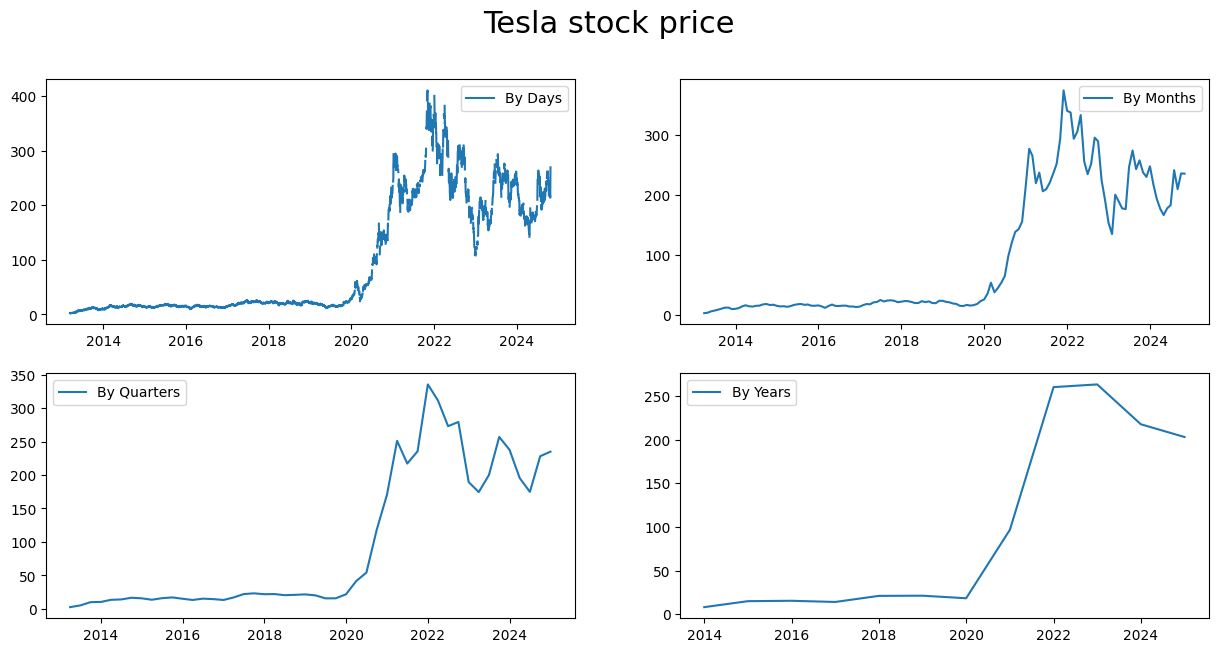

In [14]:
# PLOTS
fig = plt.figure(figsize = [15, 7])
plt.suptitle('Tesla stock price', fontsize = 22)

plt.subplot(2,2,1)
plt.plot(Day.close, '-', label = 'By Days')
plt.legend()

plt.subplot(2,2,2)
plt.plot(month.close, '-', label = 'By Months')
plt.legend()

plt.subplot(2,2,3)
plt.plot(Quarter.close, '-', label = 'By Quarters')
plt.legend()

plt.subplot(2,2,4)
plt.plot(year.close, '-', label = 'By Years')
plt.legend()

# plt.tight_layout()
plt.show()

Plotting Of Stock Price Of Each Year 

In [6]:
# An empty list to store indices where the year changes.
year_change_indices = []
previous_year = 1999

for i, date in enumerate(data['time']):
    current_year = date.year
    if current_year != previous_year:
        year_change_indices.append(i)
    previous_year = current_year

yci = year_change_indices
print("Where year changes:", yci)

Where year changes: [0, 203, 455, 707, 959, 1210, 1461, 1713, 1966, 2218, 2469, 2719]


Plotting Of Closing Price Of Each Year

In [16]:
df2 = data['close']
year = [2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024]
yeardic = pd.DataFrame({'2013':df2.iloc[:yci[1]],
            '2014':df2.iloc[yci[1]:yci[2]],
            '2015':df2.iloc[yci[2]:yci[3]],
            '2016':df2.iloc[yci[3]:yci[4]],
            '2017':df2.iloc[yci[4]:yci[5]],
            '2018':df2.iloc[yci[5]:yci[6]],
            '2019':df2.iloc[yci[6]:yci[7]],
            '2020':df2.iloc[yci[7]:yci[8]],
            '2021':df2.iloc[yci[8]:yci[9]],
            '2022':df2.iloc[yci[9]:yci[10]],
            '2023':df2.iloc[yci[10]:yci[11]],
            '2024':df2.iloc[yci[11]:]})

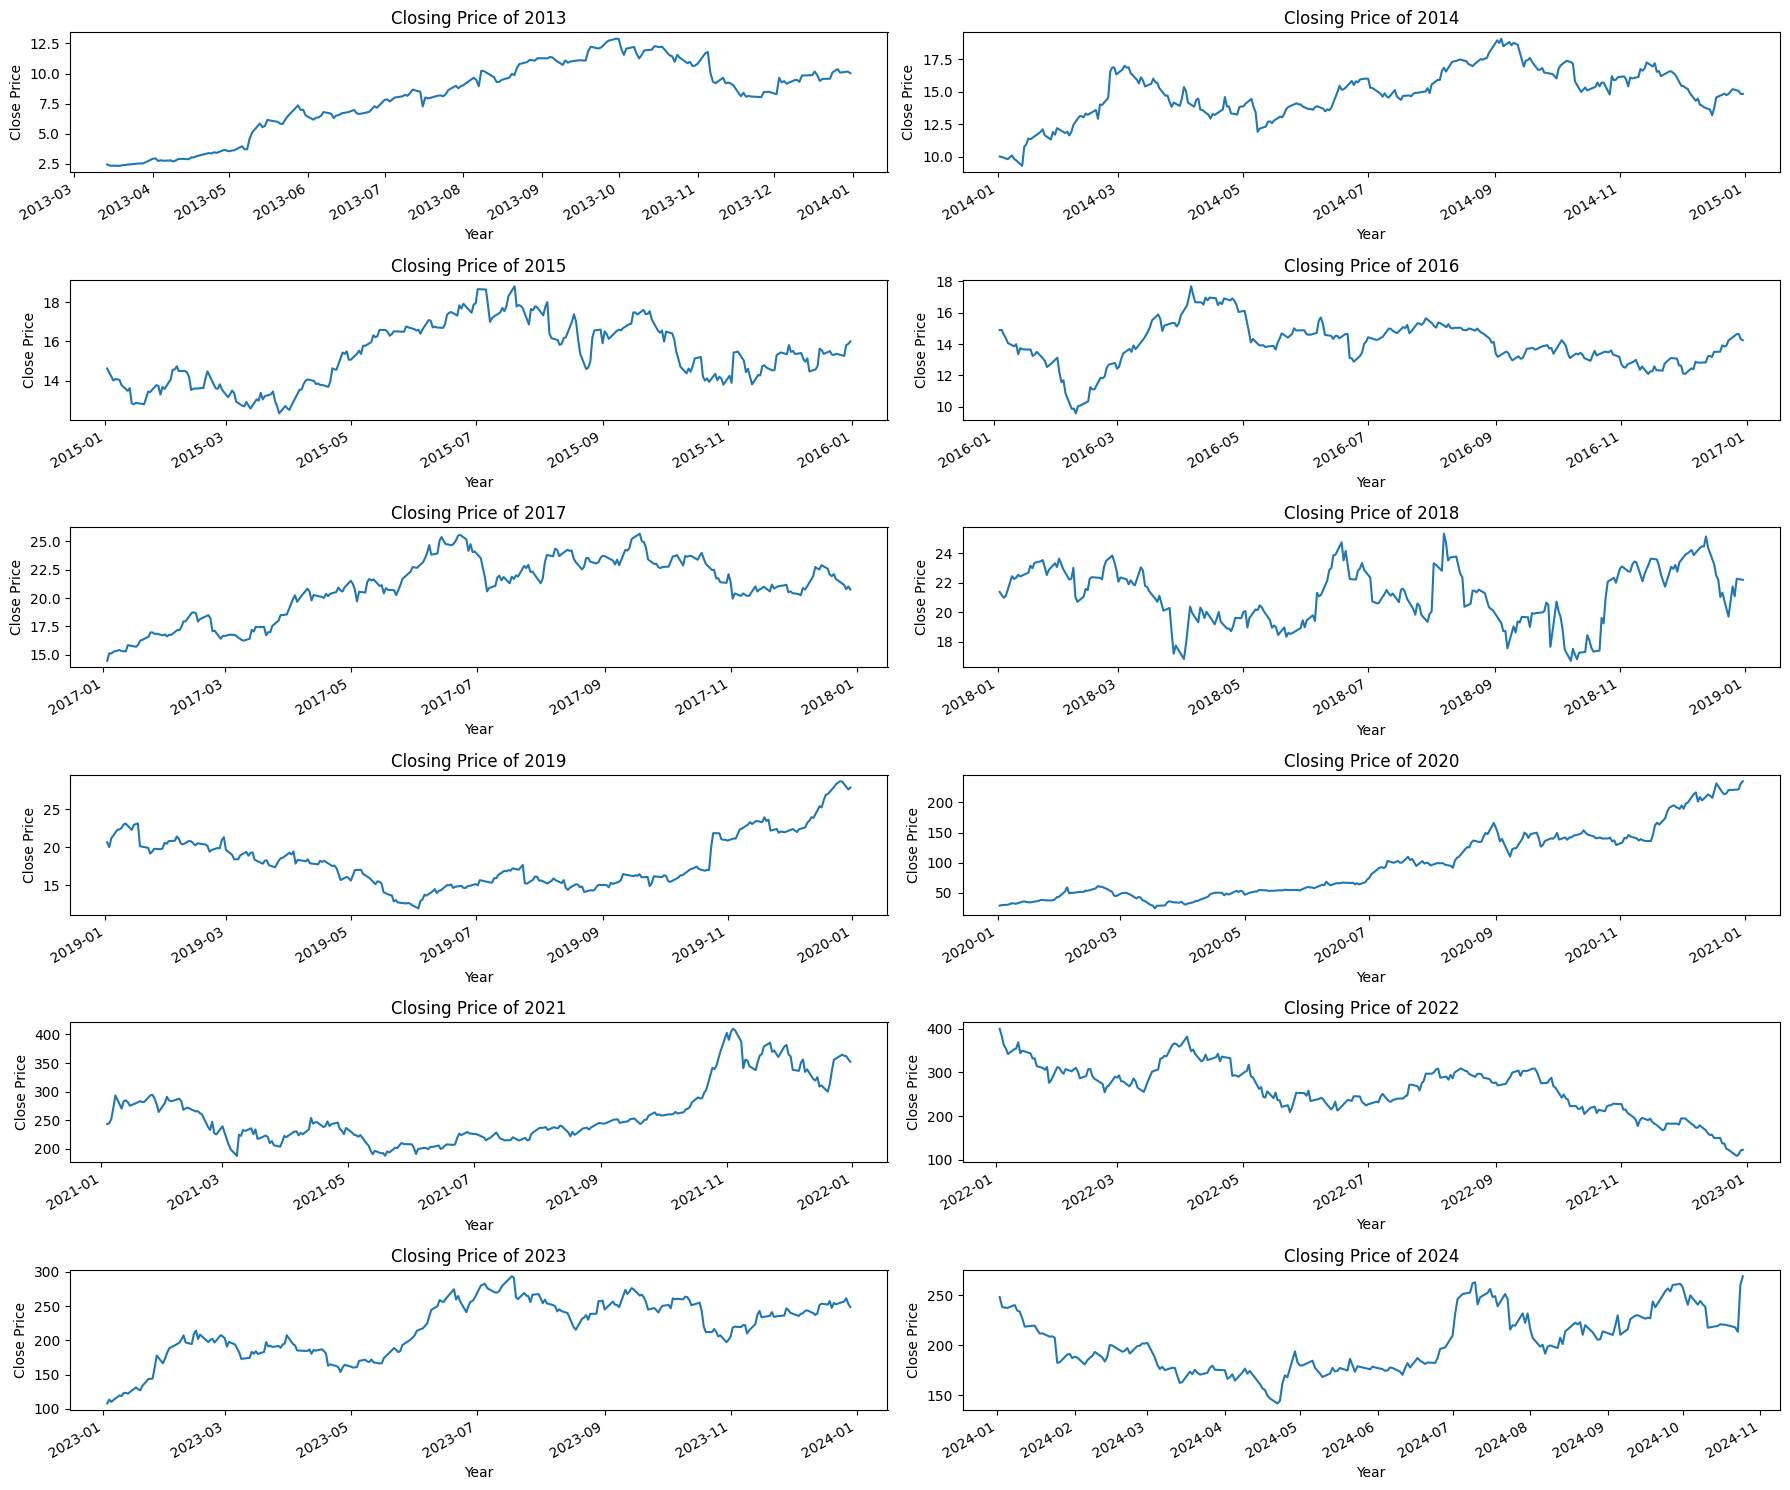

In [22]:
# Historical View Of The Closing Price
plt.figure(figsize=(18,15))

for i, yr in enumerate(yeardic, 0):  
    plt.subplot(6, 2, i+1) 
    yeardic.iloc[:, i].plot() 
    plt.ylabel('Close Price')
    plt.xlabel('Year')
    plt.title(f"Closing Price of {year[i]}")

# Adjust Layout To Prevent Overlapping
plt.tight_layout()  
plt.show()

Plotting Of Volume Of Each Year

In [23]:
df2=data['Volume']
year=[2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024]
yeardic = pd.DataFrame({'2013':df2.iloc[:203],
            '2014':df2.iloc[yci[1]:yci[2]],
            '2015':df2.iloc[yci[2]:yci[3]],
            '2016':df2.iloc[yci[3]:yci[4]],
            '2017':df2.iloc[yci[4]:yci[5]],
            '2018':df2.iloc[yci[5]:yci[6]],
            '2019':df2.iloc[yci[6]:yci[7]],
            '2020':df2.iloc[yci[7]:yci[8]],
            '2021':df2.iloc[yci[8]:yci[9]],
            '2022':df2.iloc[yci[9]:yci[10]],
            '2023':df2.iloc[yci[10]:yci[11]],
            '2024':df2.iloc[yci[11]:]})

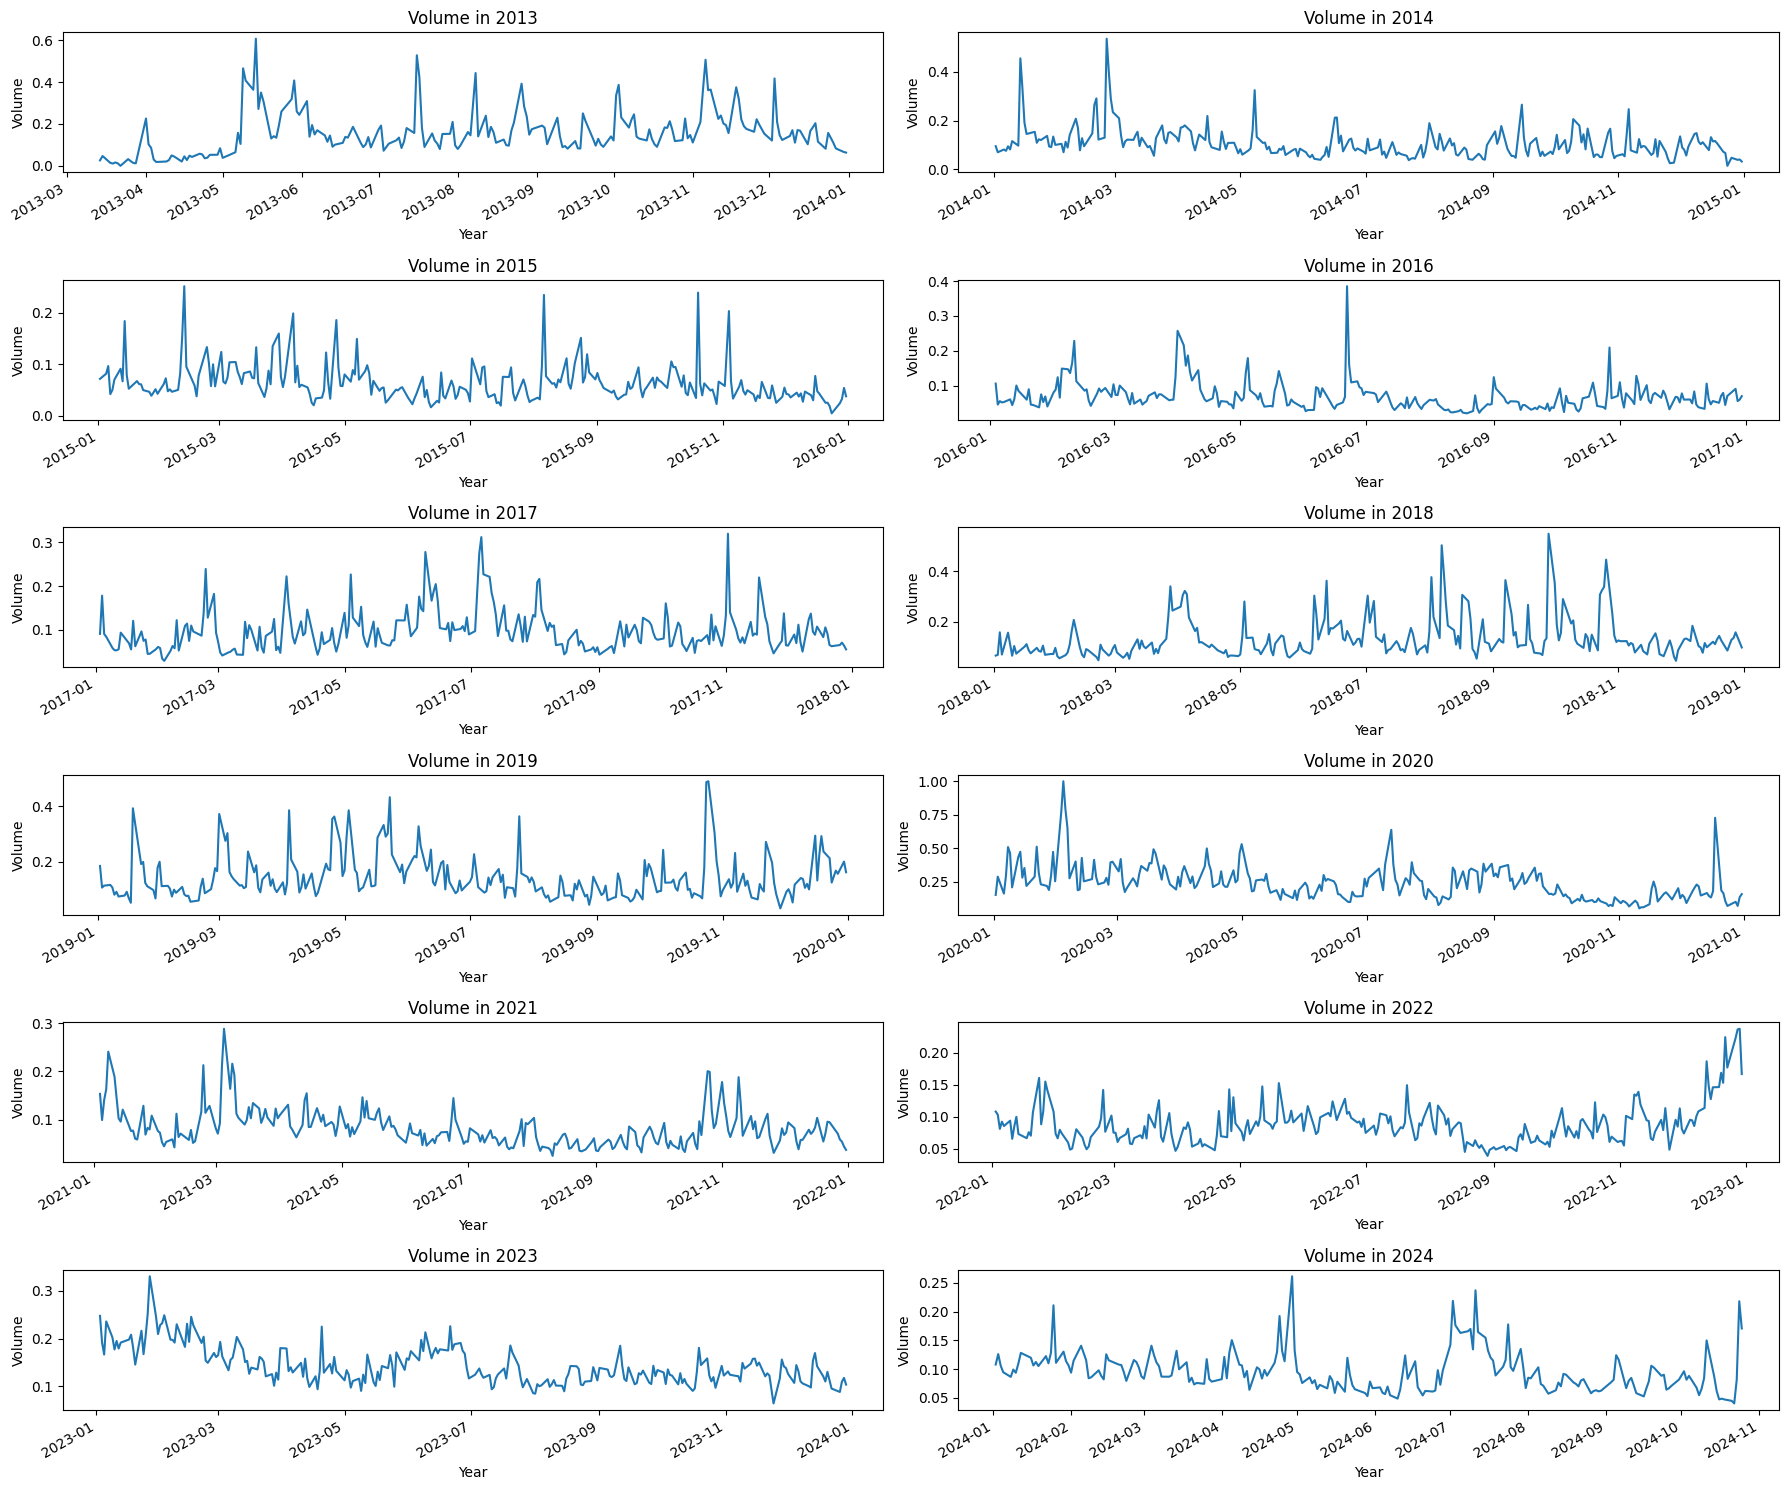

In [24]:
# Historical View Of The Volume
plt.figure(figsize = (18,15))
# plt.subplots_adjust(top = 1.25, bottom = 1.2)

for i, yr in enumerate(yeardic, 0):  
    plt.subplot(6, 2, i+1) 
    yeardic.iloc[:, i].plot() 
    plt.ylabel('Volume')
    plt.xlabel('Year')
    plt.title(f"Volume in {year[i]}")

# Adjust Layout To Prevent Overlapping
plt.tight_layout()  
plt.show()

Correlation

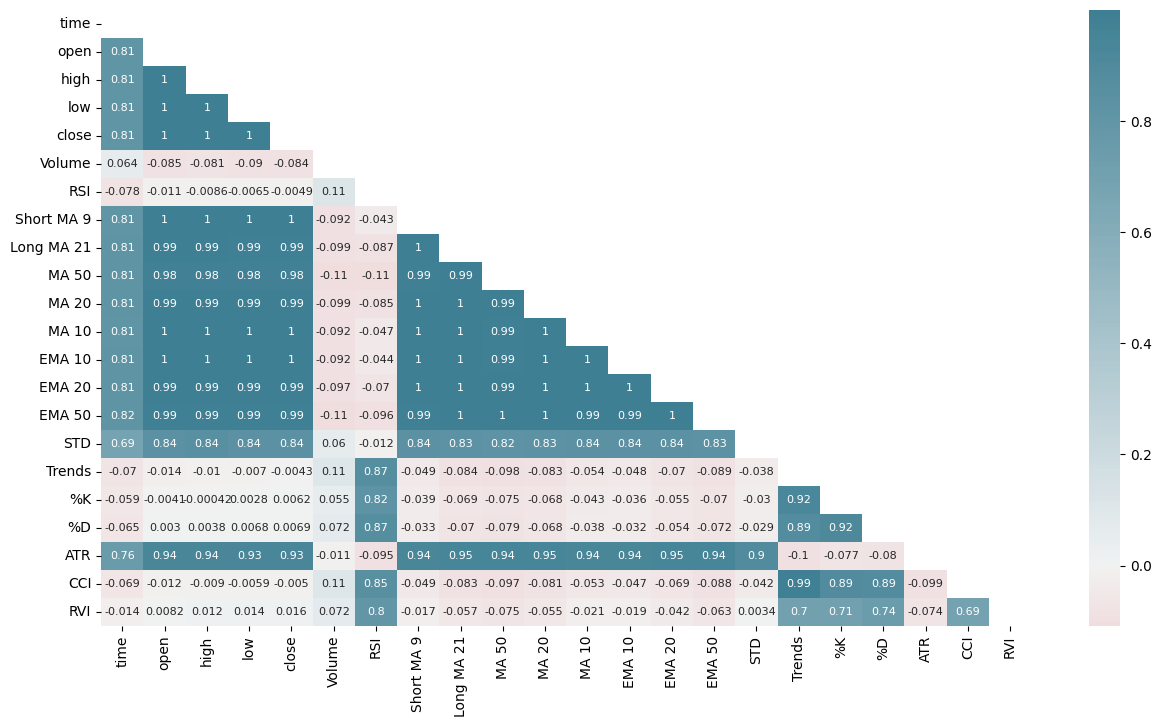

In [25]:
corr = data.corr()
plt.subplots(figsize=(15, 8))
sn.heatmap(
    corr, 
    annot = True,
    cmap = sn.diverging_palette(10, 220, as_cmap=True), 
    annot_kws = {'size': 8, 'weight': 'normal'},
    mask = np.triu(np.ones_like(corr, dtype=bool)),
    center = 0  # Ensures 0 is white
)
plt.show()

Correlation Between Closing Price And Volume

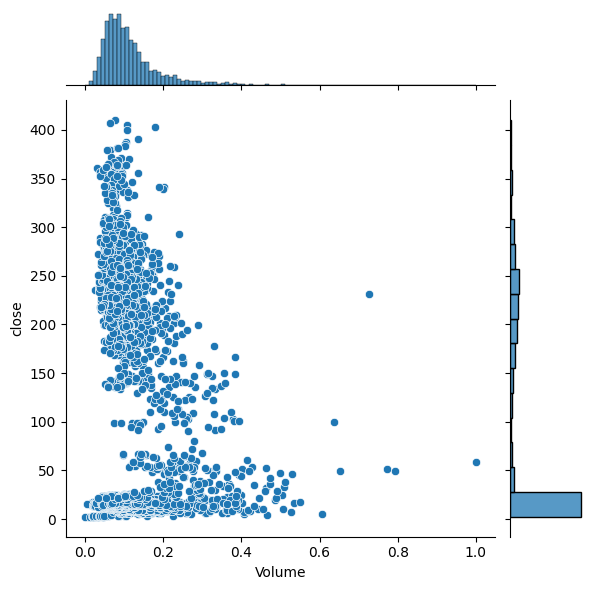

In [26]:
sn.jointplot(x = 'Volume', y = 'close', data = data, kind = 'scatter')

Plotting Of Volume And Closing Price On A Single Graph

In [27]:
# Data from 2020 to 2024
data_plot=data[['close','Volume']].copy()

scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data1 = pd.DataFrame(scaler.fit_transform(data_plot), columns = data_plot.columns, index = data_plot.index)

In [28]:
df2=scaled_data1.copy()
yeardic1 = {
    '2020': df2.iloc[yci[7]:yci[8]],
    '2021': df2.iloc[yci[8]:yci[9]],
    '2022': df2.iloc[yci[9]:yci[10]],
    '2023': df2.iloc[yci[10]:yci[11]],
    '2024': df2.iloc[yci[11]:]
}

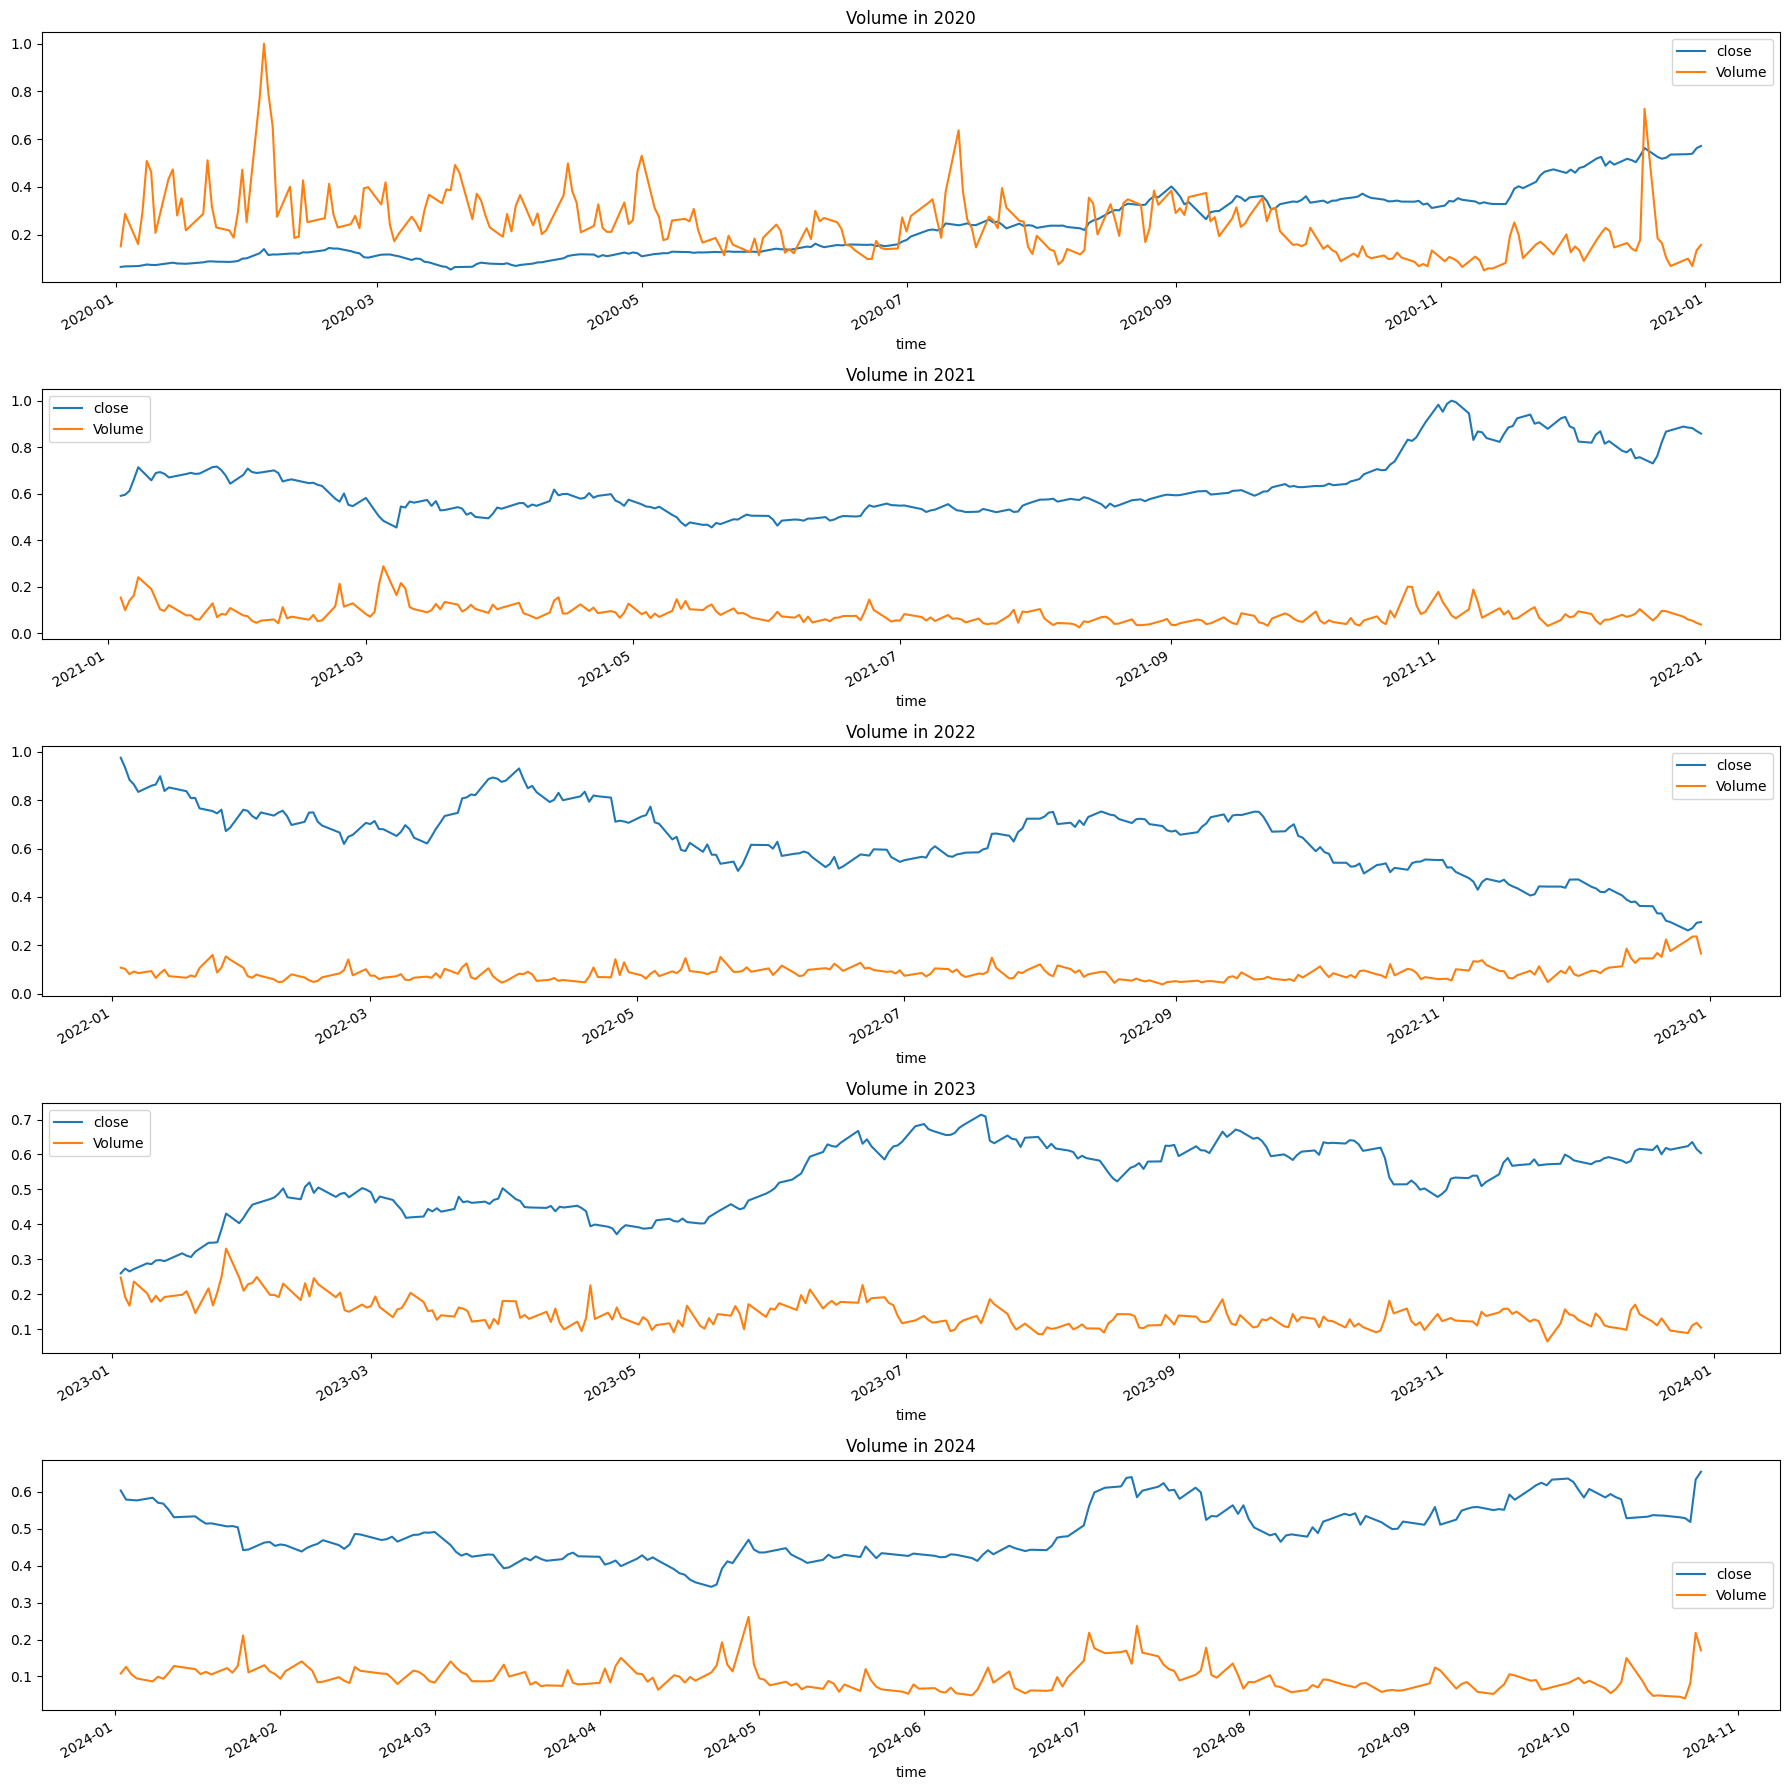

In [29]:
plt.figure(figsize=(18, 18))

# Iterate Over The Dictionary Of DataFrames
for i, (yr, df) in enumerate(yeardic1.items(), 0):  
    plt.subplot(5,1,i + 1)
    df[['close','Volume']].plot(ax=plt.gca())  
    plt.legend()
    plt.title(f"Volume in {yr}")

plt.tight_layout()  
plt.show()


Plotting Of RSI And Closing Price On A Single Graph

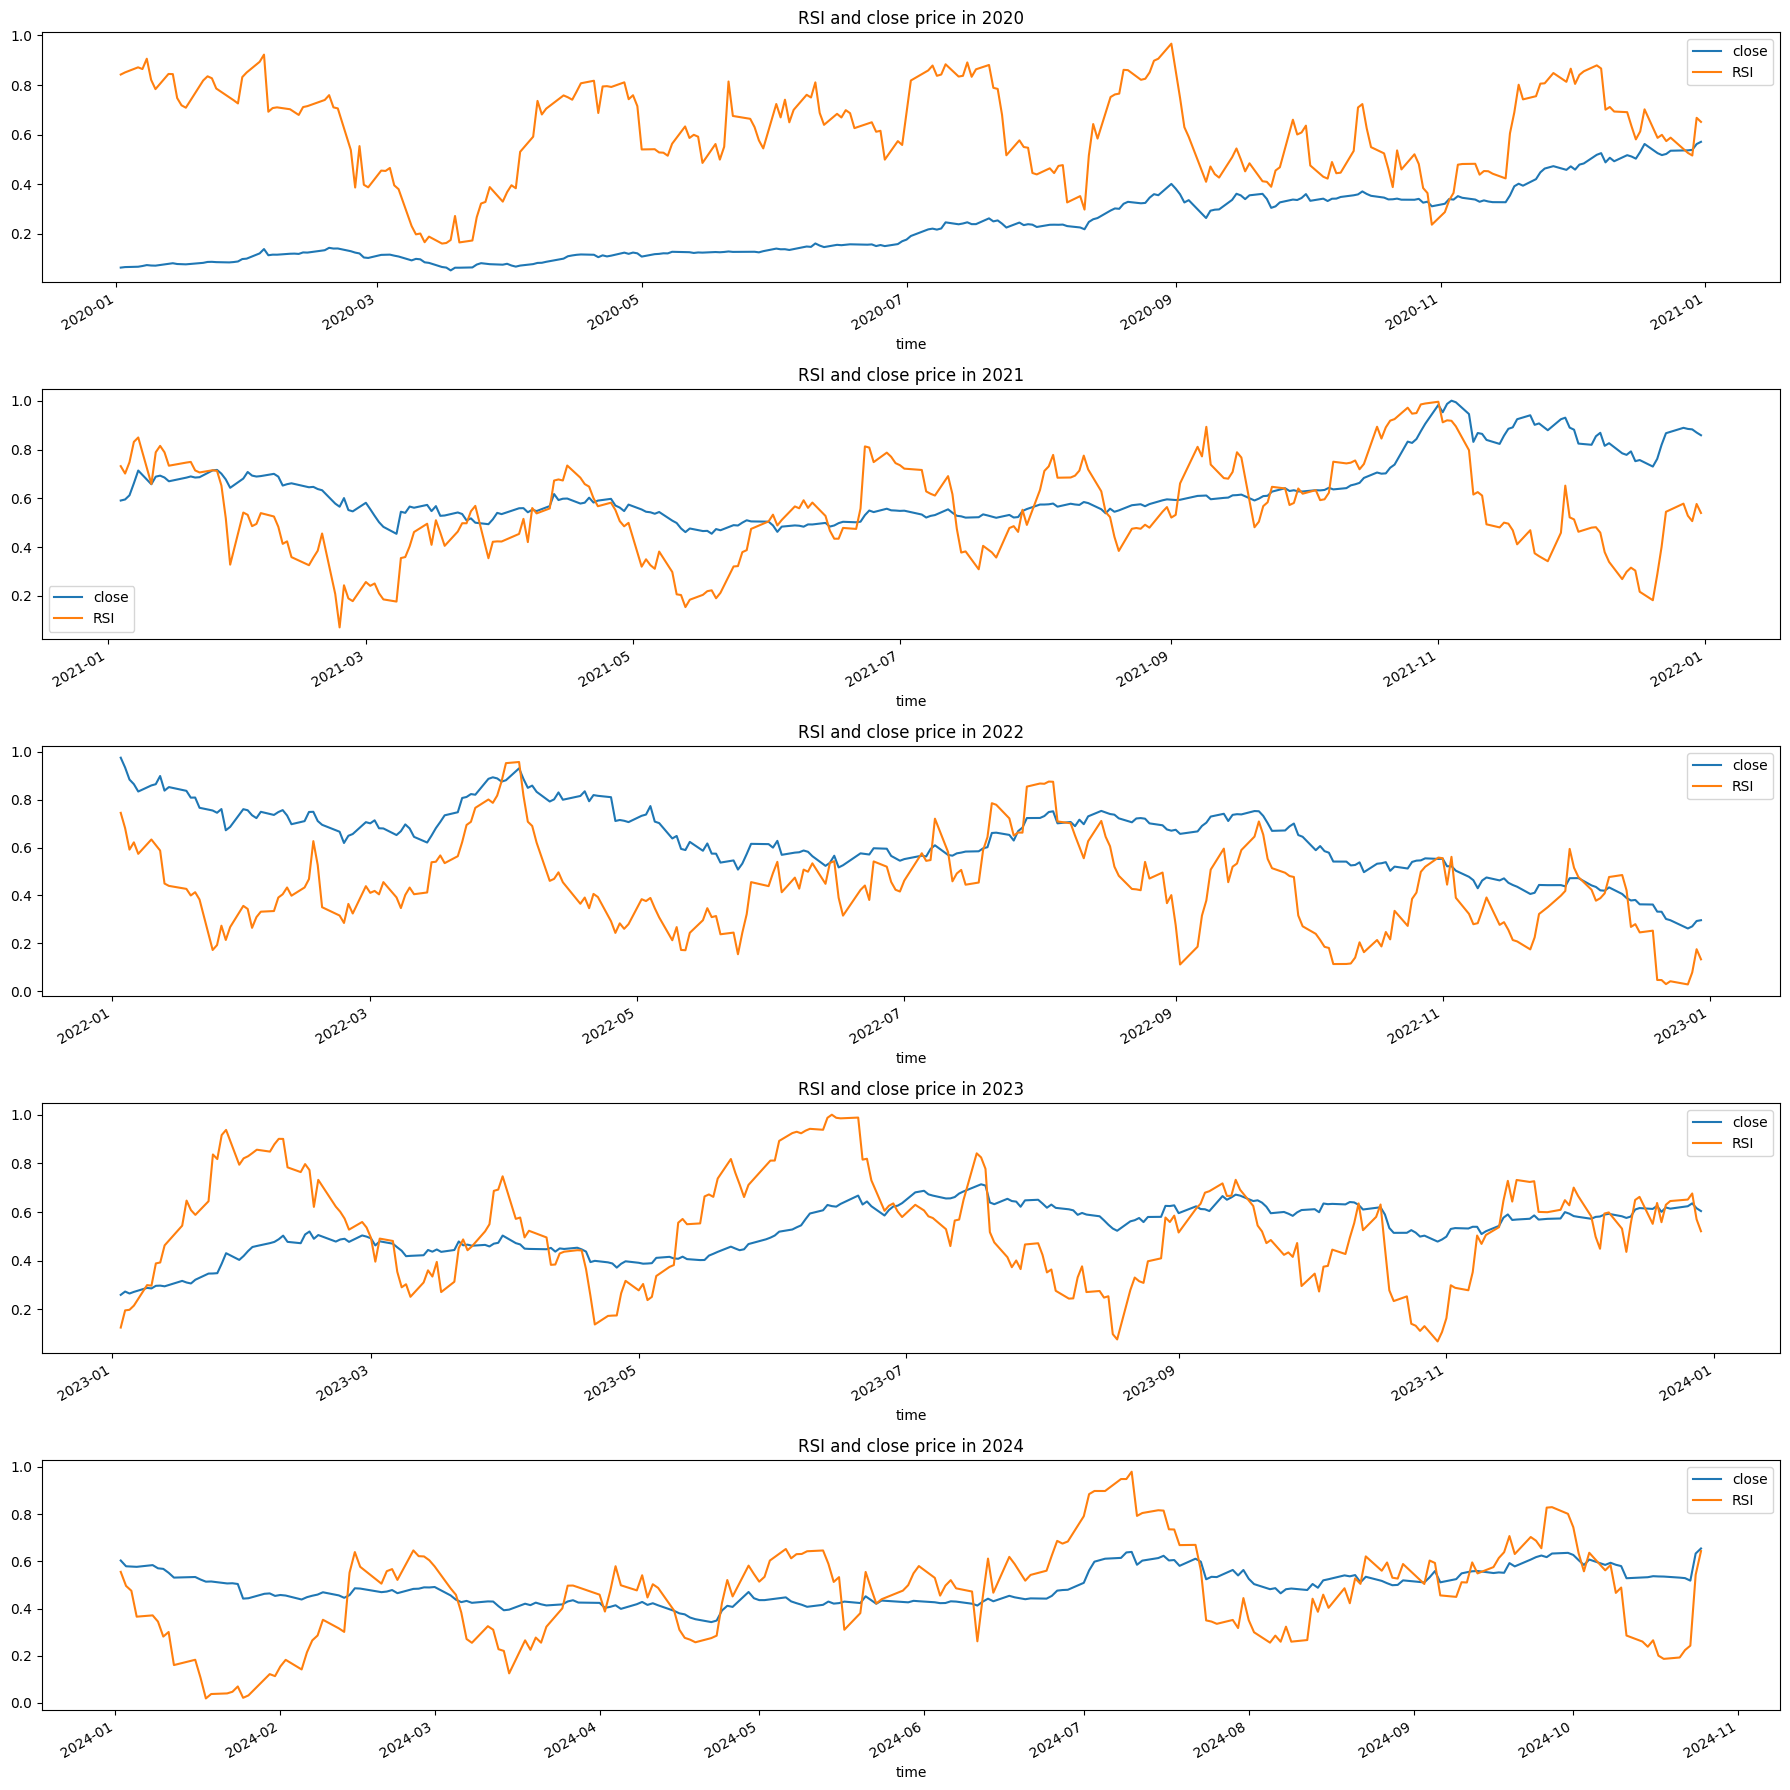

In [30]:
# Data From 2020 To 2024
data_plot2=data[['close','RSI']].copy()


scaled_data2 = pd.DataFrame(scaler.fit_transform(data_plot2), columns=data_plot2.columns, index=data_plot2.index)

df2=scaled_data2.copy()
yeardic2 = {
    '2020': df2.iloc[yci[7]:yci[8]],
    '2021': df2.iloc[yci[8]:yci[9]],
    '2022': df2.iloc[yci[9]:yci[10]],
    '2023': df2.iloc[yci[10]:yci[11]],
    '2024': df2.iloc[yci[11]:]
}
plt.figure(figsize = (18, 18))

# Iterate Over The Dictionary Of DataFrames
for i, (yr, df) in enumerate(yeardic2.items(), 0):  
    plt.subplot(5,1,i + 1)
    df[['close','RSI']].plot(ax = plt.gca())  
    plt.legend()
    plt.title(f"RSI and close price in {yr}")

plt.tight_layout()  
plt.show()


Plotting Of Trends And Closing Price On A Single Graph

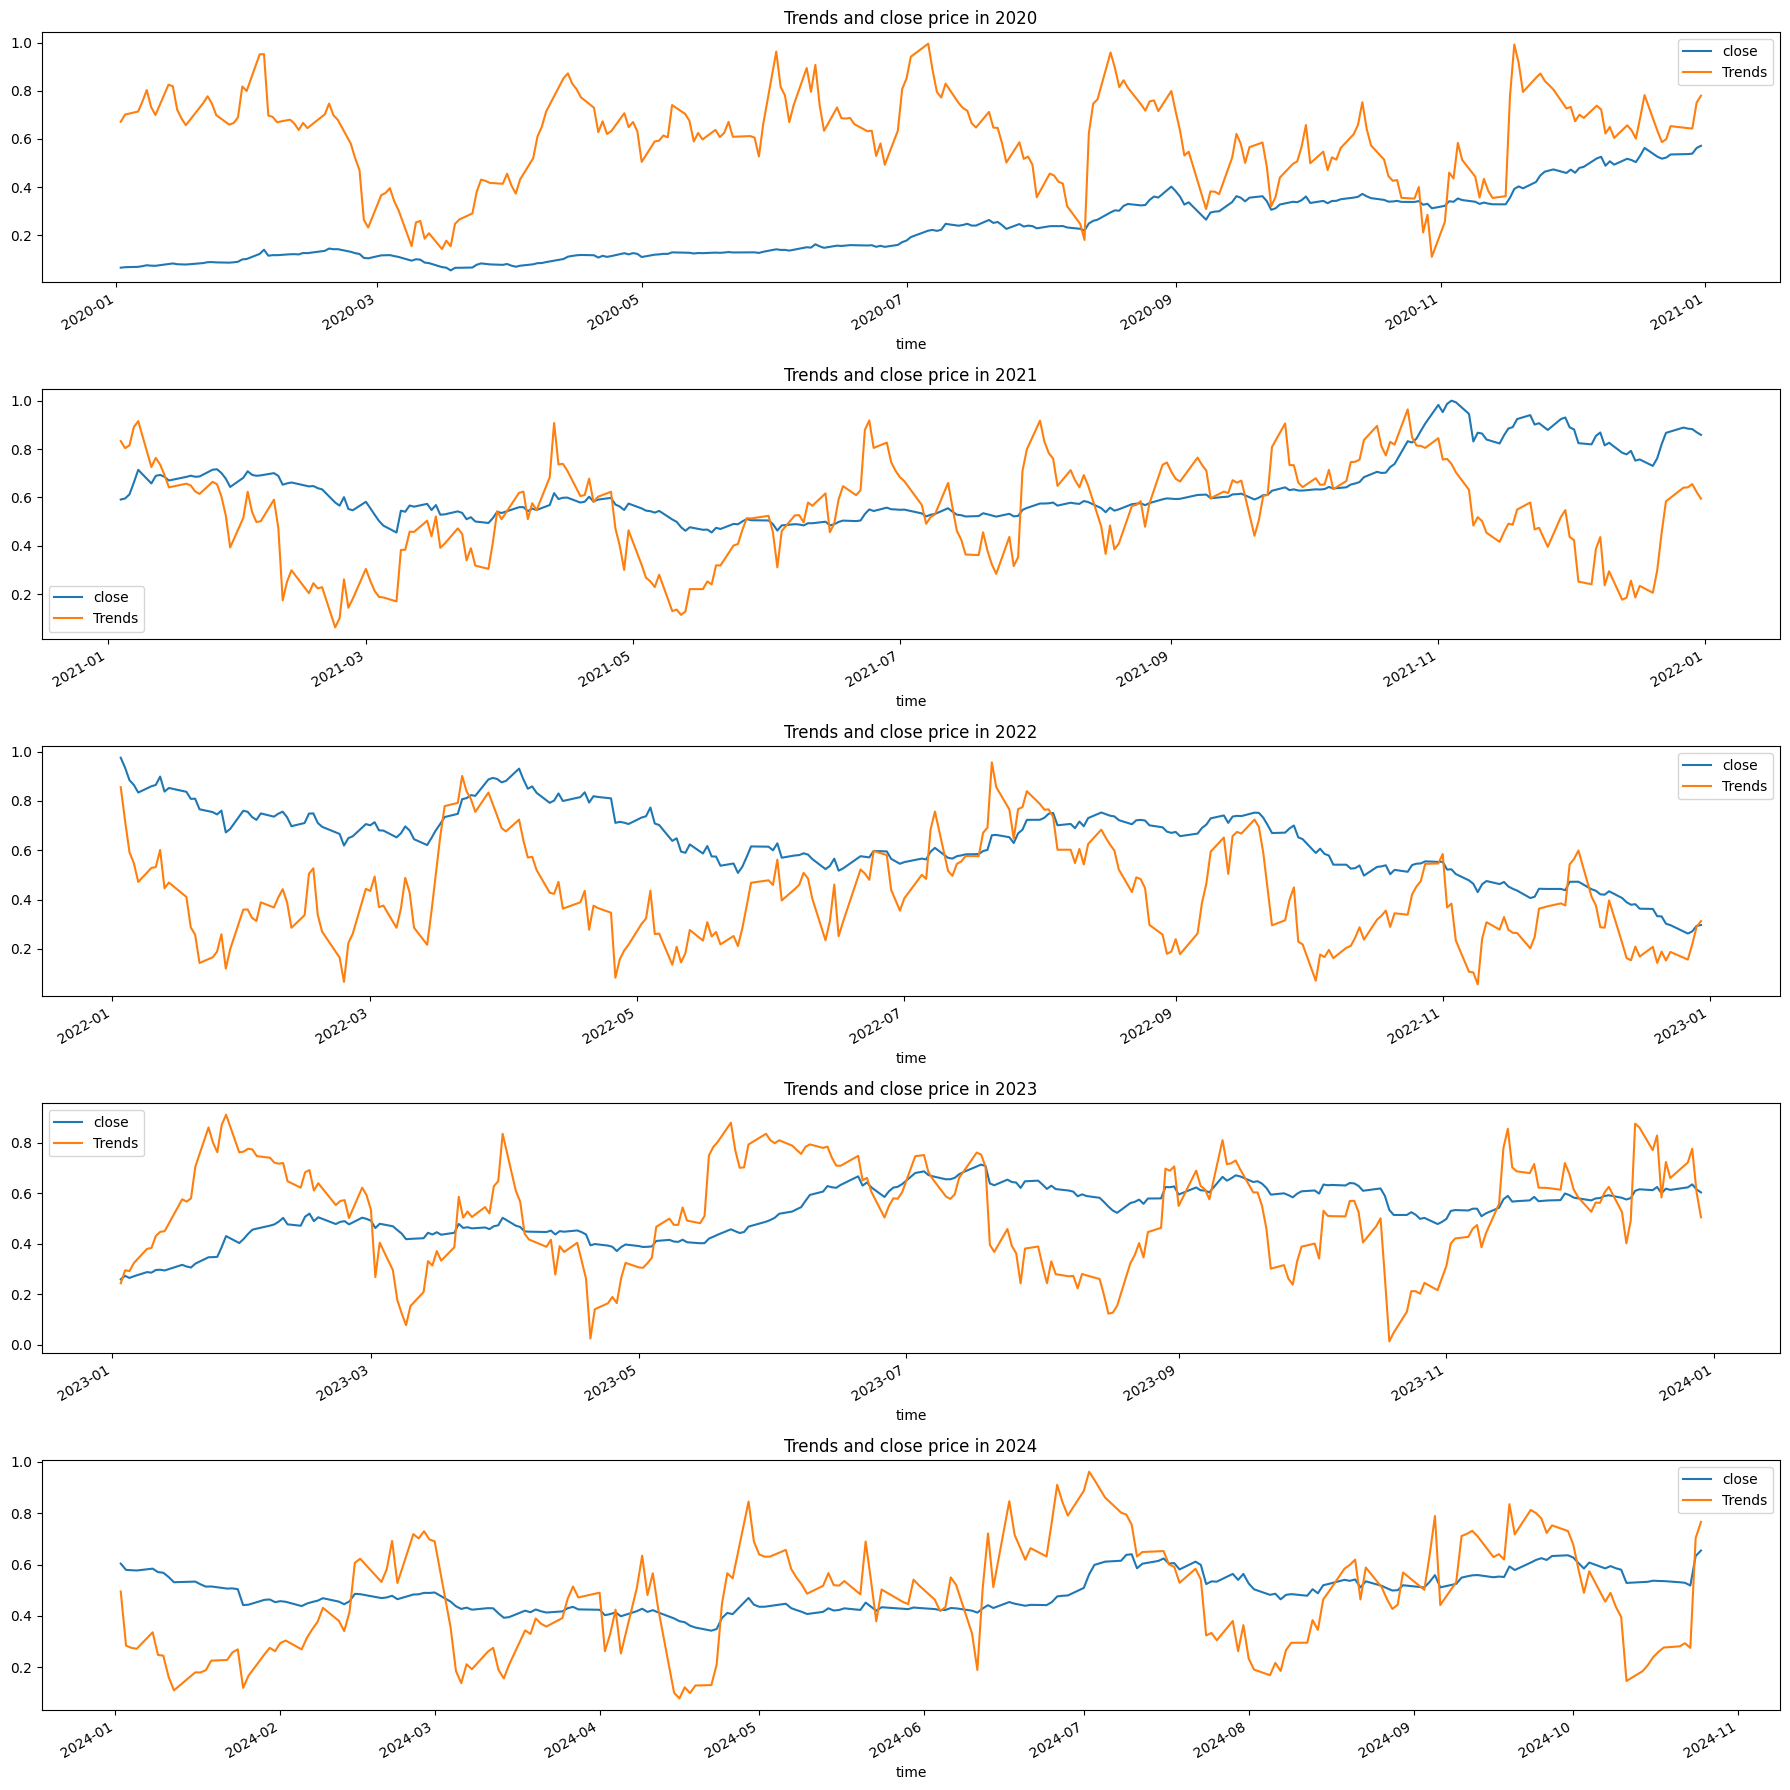

In [31]:
# Data From 2020 To 2024
data_plot3=data[['close','Trends']].copy()

scaled_data3 = pd.DataFrame(scaler.fit_transform(data_plot3), columns = data_plot3.columns, index = data_plot3.index)

df2=scaled_data3.copy()
yeardic3 = {
    '2020': df2.iloc[yci[7]:yci[8]],
    '2021': df2.iloc[yci[8]:yci[9]],
    '2022': df2.iloc[yci[9]:yci[10]],
    '2023': df2.iloc[yci[10]:yci[11]],
    '2024': df2.iloc[yci[11]:]
}
plt.figure(figsize=(18, 18))

# Iterate Over The Dictionary Of DataFrames
for i, (yr, df) in enumerate(yeardic3.items(), 0):  
    plt.subplot(5,1,i + 1)
    df[['close','Trends']].plot(ax=plt.gca())  
    plt.legend()
    plt.title(f"Trends and close price in {yr}")

plt.tight_layout()  
plt.show()


By comparing (Volume, RSI, Trend) and the closing price, we can see that when (Volume, RSI, Trend) increases or decreases, the closing price changes along with it, even there is only a small change in close price.
Even the correlation is weak, but (Volume, RSI, Trend) still remain a good input feature to predict the price

# ARIMA model

In [ ]:
import statsmodels.api as sm
from scipy import stats

as we see before, in the monthly figure provide a clearer picture of the trend without much noise, hence we predict the monthly closing price

In [33]:
arima_stk1 = stock[['time','open','high','low','close','Volume']].copy()

Stationary check

In [34]:
# month data is from above visualize part
print("Dickey-Fuller test: p=%f" % sm.tsa.stattools.adfuller(month.close)[1])

Dickey-Fuller test: p=0.705237


low p-value means stationary (p<0.05), arima will produce unreliable forecast with non-stationary data.
Next, transform to stationary

Box-Cox Transformation
do this first to make it more likely as normal distribution
cuz straight away diffentiate will destroy the data too much

In [35]:
month['close_box'], lmbda = stats.boxcox(month.close)
print("Dickey-Fuller test: p=%f" % sm.tsa.stattools.adfuller(month['close_box'])[1])

Dickey-Fuller test: p=0.223640


Still not stationary

Do Seasonal differentiation

In [36]:
month['close_box_diff'] = month.close_box-month.close_box.shift(12)
print("Dickey-Fuller test: p=%f" % sm.tsa.stattools.adfuller(month.close_box_diff[12:])[1])
#shift(12) to compare every month to previous year's month

Dickey-Fuller test: p=0.263653


Regular differentiation

In [37]:
month['close_box_diff2'] = month.close_box_diff-month.close_box_diff.shift(1)
print("Dickey-Fuller test: p=%f" % sm.tsa.stattools.adfuller(month.close_box_diff2[13:])[1])

Dickey-Fuller test: p=0.000536


the close price data is now stationary

STL decomposition

<Figure size 640x480 with 0 Axes>

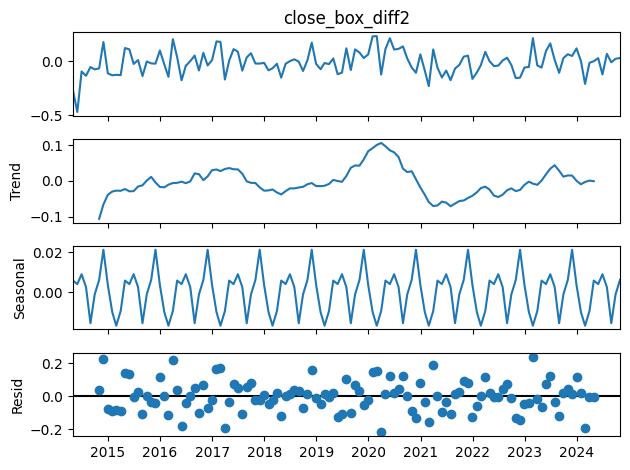

In [38]:
plt.figure()
sm.tsa.seasonal_decompose(month.close_box_diff2[13:]).plot()
plt.show()

In [39]:
month.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 140 entries, 2013-03-31 to 2024-10-31
Freq: M
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   time             140 non-null    datetime64[ns]
 1   close            140 non-null    float64       
 2   close_box        140 non-null    float64       
 3   close_box_diff   128 non-null    float64       
 4   close_box_diff2  127 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 6.6 KB


In [40]:
stkkkk = month[['close','close_box']]

In [41]:
# Set the train data be the value from 2013 to 2023, 
# let the 2024 data to be a test dataset
arima_train_data = stkkkk.iloc[:130]
sd = arima_train_data.index[0]
ed = arima_train_data.index[-1]

print('Starting Date',sd)
print('Ending Date',ed)

Starting Date 2013-03-31 00:00:00
Ending Date 2023-12-31 00:00:00


In [42]:
# take one more value is to take a more clear connection 
# With the prediction of test data in graph
arima_test_data=stkkkk.iloc[129:]
sd = arima_test_data.index[0]
ed = arima_test_data.index[-1]

print('Starting Date',sd)
print('Ending Date',ed)

Starting Date 2023-12-31 00:00:00
Ending Date 2024-10-31 00:00:00


In [53]:
arima_model=sm.tsa.statespace.SARIMAX(arima_train_data.close_box, order=(3,1,3),
                                      seasonal_order=(2,1,2,12), enforce_stationarity=False,
                                      enforce_invertibility=False).fit(disp=-1)

C:\Users\Kai\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [54]:
print(arima_model.summary())

                                        SARIMAX Results                                        
Dep. Variable:                               close_box   No. Observations:                  130
Model:             SARIMAX(3, 1, 3)x(2, 1, [1, 2], 12)   Log Likelihood                 107.728
Date:                                 Wed, 04 Dec 2024   AIC                           -193.456
Time:                                         18:14:31   BIC                           -166.081
Sample:                                     03-31-2013   HQIC                          -182.422
                                          - 12-31-2023                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5554      0.999      0.556      0.578      -1.402       2

In [55]:
def invboxcox(y,lmbda):
    if lmbda == 0:
        return(np.exp(y))
    else:
        return(np.exp(np.log(lmbda*y+1) / lmbda))

In [56]:
arima_predict_test=pd.DataFrame(index=arima_test_data.index, columns=arima_test_data.columns)
pred=invboxcox(arima_model.predict(start=100, end=150),lmbda)
arima_predict_test['predict'] = pred

In [57]:
arima_predict_train=pd.DataFrame(index=arima_train_data.index, columns=arima_train_data.columns)
pred2=invboxcox(arima_model.predict(start=0, end=150),lmbda)
arima_predict_train['predict'] = pred2

modify the dataframe to make it suitable for evaluation

In [58]:
y_ari_train_prediction=arima_predict_train['predict'].copy()
y_ari_train = arima_train_data['close'].copy()

y_ari_test_prediction=arima_predict_test['predict'].copy()
y_ari_test = arima_test_data['close'].copy()

print("Y_train predict:", y_ari_train_prediction.shape) 
print("y_train:", y_ari_train.shape) 

print("x_test predict:", y_ari_test_prediction.shape)
print("y_test :", y_ari_test.shape)

Y_train predict: (130,)
y_train: (130,)
x_test predict: (11,)
y_test : (11,)


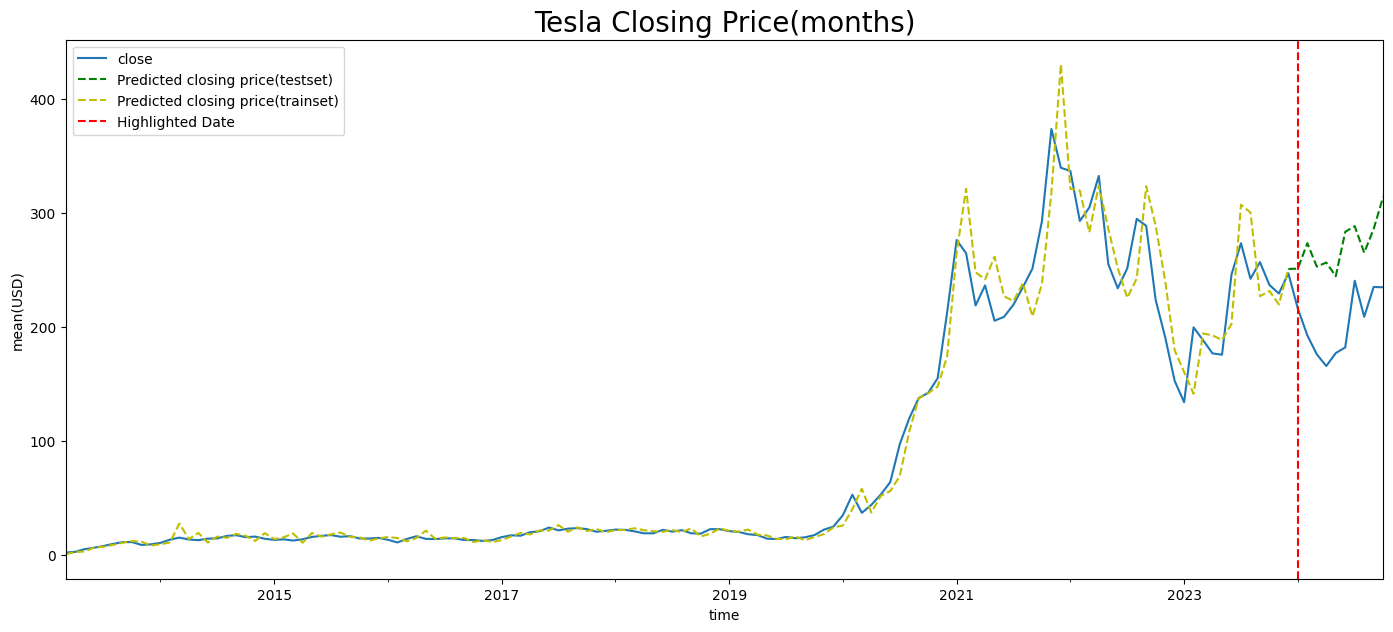

In [59]:
plt.figure(figsize = (17,7))
stkkkk.close.plot() 
y_ari_test_prediction.plot(color = 'g',ls = '--', label = 'Predicted closing price(testset)')
y_ari_train_prediction.plot(color = 'y',ls = '--', label = 'Predicted closing price(trainset)')

highlight_date = '2024-01-1'  # Replace with your desired date
plt.axvline(pd.to_datetime(highlight_date), color = 'r', linestyle = '--', label = 'Highlighted Date')

plt.legend()
plt.title('Tesla Closing Price(months)',fontsize = 20)
plt.ylabel('mean(USD)')
plt.show()

Evaluate

In [60]:
# Make predictions on the test set
print("Using test dataset to evaluate model (test set):")
MSE = ms.mean_squared_error(y_ari_test,y_ari_test_prediction)
print("MSE:",MSE)
RMSE = math.sqrt(ms.mean_squared_error(y_ari_test,y_ari_test_prediction))
print("RMSE:", RMSE)
MAE = ms.mean_absolute_error(y_ari_test,y_ari_test_prediction)
print('MAE:',MAE)
MAPE = np.mean(np.abs((y_ari_test - y_ari_test_prediction) /y_ari_test)) * 100
print('MAPE:',MAPE)

EVS = ms.explained_variance_score(y_ari_test,y_ari_test_prediction)
print("Explained variance regression score:", EVS)

R2 = ms.r2_score(y_ari_test,y_ari_test_prediction)
print("R2-score:",R2)

Using test dataset to evaluate model (test set):
MSE: 4634.546746453203
RMSE: 68.07750543647441
MAE: 62.70206739687515
MAPE: 32.142610183958254
Explained variance regression score: 0.11552374553984324
R2-score: -4.830954736212693


In [61]:
# Make predictions on the train set
print("Using test dataset to evaluate model (train set):")
MSE = ms.mean_squared_error(y_ari_train,y_ari_train_prediction)
print("MSE:",MSE)
RMSE = math.sqrt(ms.mean_squared_error(y_ari_train,y_ari_train_prediction))
print("RMSE:", RMSE)
MAE = ms.mean_absolute_error(y_ari_train,y_ari_train_prediction)
print('MAE:',MAE)
MAPE = np.mean(np.abs((y_ari_train - y_ari_train_prediction) /y_ari_test)) * 100
print('MAPE:',MAPE)

EVS = ms.explained_variance_score(y_ari_train,y_ari_train_prediction)
print("Explained variance regression score:", EVS)

R2 = ms.r2_score(y_ari_train,y_ari_train_prediction)
print("R2-score:",R2)

Using test dataset to evaluate model (train set):
MSE: 418.513971313814
RMSE: 20.457614018106167
MAE: 10.905491434271829
MAPE: 1.5213445679419066
Explained variance regression score: 0.9631412515964162
R2-score: 0.9629974392182469


# LSTM

In [3]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

In [4]:
LSTM_stk = stock.copy()

In [5]:
# Changing The Time Format To A Machine Readable Form (Suitable To Plot A Time Graph)
# Just for understanding
LSTM_stk.time = pd.to_datetime(LSTM_stk.time, dayfirst = True)
LSTM_stk.index = LSTM_stk.time
LSTM_stk.head()

,time,open,high,low,close,Volume,RSI,Short MA 9,Long MA 21,MA 50,...,EMA 10,EMA 20,EMA 50,STD,Trends,%K,%D,ATR,CCI,RVI
time,,,,,,,,,,,,,,,,,,,,,
2013-03-14,2013-03-14,2.593330,2.593997,2.451331,2.456665,0.026159,53.838230,2.523479,2.466474,2.432358,...,2.512953,2.487852,2.449882,0.118244,48.950099,53.602893,79.655205,0.091095,22.690672,47.021893
2013-03-15,2013-03-15,2.442664,2.443330,2.347332,2.352664,0.046909,54.804588,2.521331,2.456442,2.432264,...,2.483809,2.474977,2.446070,0.118567,29.139768,26.186158,56.941903,0.087429,-50.659005,48.066923
2013-03-18,2013-03-18,2.353331,2.403998,2.327998,2.343330,0.014454,53.765675,2.510220,2.446442,2.432771,...,2.458268,2.462439,2.442041,0.120900,28.914881,17.175253,32.321435,0.087333,-59.764561,47.718111
2013-03-19,2013-03-19,2.349998,2.373332,2.329331,2.338664,0.010853,49.888337,2.490886,2.440220,2.433677,...,2.436522,2.450651,2.437987,0.115875,30.014351,15.839569,19.733660,0.085667,-61.749274,45.135615
2013-03-20,2013-03-20,2.350664,2.404665,2.343998,2.396664,0.016229,55.857682,2.473997,2.429648,2.435824,...,2.429275,2.445509,2.436366,0.111395,44.164885,32.442591,21.819138,0.082143,-34.009956,50.309758


In [6]:
year_change_indices = []
previous_year = 1999

for i, date in enumerate(LSTM_stk['time']):
    
    current_year = date.year
    if current_year != previous_year:
        year_change_indices.append(i)
    previous_year = current_year

yci = year_change_indices
print("Indices where year changes:", yci)

Indices where year changes: [0, 203, 455, 707, 959, 1210, 1461, 1713, 1966, 2218, 2469, 2719]


Taking Data From 2019 until The Present

In [7]:
data2 = LSTM_stk.iloc[yci[6]:]
data2.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1465 entries, 2019-01-02 to 2024-10-25
Data columns (total 22 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   time        1465 non-null   datetime64[ns]
 1   open        1465 non-null   float64       
 2   high        1465 non-null   float64       
 3   low         1465 non-null   float64       
 4   close       1465 non-null   float64       
 5   Volume      1465 non-null   float64       
 6   RSI         1465 non-null   float64       
 7   Short MA 9  1465 non-null   float64       
 8   Long MA 21  1465 non-null   float64       
 9   MA 50       1465 non-null   float64       
 10  MA 20       1465 non-null   float64       
 11  MA 10       1465 non-null   float64       
 12  EMA 10      1465 non-null   float64       
 13  EMA 20      1465 non-null   float64       
 14  EMA 50      1465 non-null   float64       
 15  STD         1465 non-null   float64       
 16  Trends

In [8]:
# Retaining Only The Close Price Column
LSTM_data = data2.filter(['close'])

# This is because LSTMs are commonly used for time series forecasting, and in this case, the model is expected to predict the close price. 
# Hence, only the close price is retained for training and testing.

# Convert The Dataframe To A Numpy Array
LSTM_dataset = LSTM_data.values

# Machine learning models, including LSTMs, typically require input data in the form of NumPy arrays for efficient computation.
# Converting the DataFrame to a NumPy array ensures compatibility with deep learning frameworks like TensorFlow/Keras.

In [9]:
# Scaling The Closing Price Into Range Between 0 And 1
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(LSTM_dataset)

In [10]:
# Spliting The Data Into 85% Training Size And 15% Testing Size 
# Validation Set Is Not Implemented As It May Cause The Model To Underperform Due To The Limited Size Of The Dataset

LSTM_train_size = int(len(LSTM_dataset) * 0.85)

LSTM_train_data, LSTM_test_data = scaled_data[:LSTM_train_size], scaled_data[LSTM_train_size:]

print(LSTM_train_size)

1245


In time series analysis, a time_step (or "lookback window") is used to capture the sequential information of past values. For an LSTM (Long Short-Term Memory) model, the time_step represents the number of previous time points that the model considers to make a prediction for the current time point.

In [11]:
# Convert an array of values into a dataset matrix and format it for LSTM input
def create_dataset(df, time_step = 1, print_samples = False):
    x_train, y_train = [], []
    for i in range(time_step, len(df)):
        
        # Collect a window of 'time_step' length
        x_train.append(df[i - time_step:i, 0])

        # The target (actual) value is the next value in the sequence
        y_train.append(df[i, 0])
        
    # Convert lists to numpy arrays
    x_train, y_train = np.array(x_train), np.array(y_train)
    
    # Reshape x_train to fit LSTM input format: (samples, time steps, features)
    x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
    
    return x_train, y_train


In [12]:
time_step = 31
X_LSTM_train, y_LSTM_train = create_dataset(LSTM_train_data, time_step = time_step)

X_LSTM_test, y_LSTM_test = create_dataset(LSTM_test_data, time_step = time_step)

print("x_train shape:", X_LSTM_train.shape)  
print("y_train shape:", y_LSTM_train.shape)  

print("x_test shape:", X_LSTM_test.shape)
print("y_test shape:", y_LSTM_test.shape)

x_train shape: (1214, 31, 1)
y_train shape: (1214,)
x_test shape: (189, 31, 1)
y_test shape: (189,)


Can add more layer to get a better result, but need to be careful about overfitting

In [13]:
# Construction Of LSTM Model
LSTM_model = Sequential()
LSTM_model.add(LSTM(128, return_sequences = True, input_shape = (X_LSTM_train.shape[1], 1)))
LSTM_model.add(LSTM(64, return_sequences = True))
LSTM_model.add(LSTM(32, return_sequences = False))

LSTM_model.add(Dense(25))
LSTM_model.add(Dense(1))

C:\Users\Kai\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
LSTM_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 31, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 31, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │           825 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,235 (504.82 KB)

 Trainable params: 129,235 (504.82 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Compiling The Model
LSTM_model.compile(optimizer = 'adam', loss = 'mean_squared_error',metrics = ['mae'])

In [16]:
LSTM_history = LSTM_model.fit(X_LSTM_train,y_LSTM_train,validation_data = (X_LSTM_test,y_LSTM_test),epochs = 30,batch_size = 32,verbose = 1)

Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0541 - mae: 0.1567 - val_loss: 0.0029 - val_mae: 0.0424
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0036 - mae: 0.0410 - val_loss: 0.0030 - val_mae: 0.0438
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0031 - mae: 0.0367 - val_loss: 0.0027 - val_mae: 0.0391
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0027 - mae: 0.0364 - val_loss: 0.0024 - val_mae: 0.0361
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0031 - mae: 0.0383 - val_loss: 0.0021 - val_mae: 0.0355
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0022 - mae: 0.0318 - val_loss: 0.0018 - val_mae: 0.0316
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0022 - mae: 0.0329 - val_loss: 0.0018 - val_mae: 0.0320
Epoch 8/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0021 - mae: 0.0317 - val_loss: 0.0021 - val_mae: 0.0334
Epoch 9/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.001

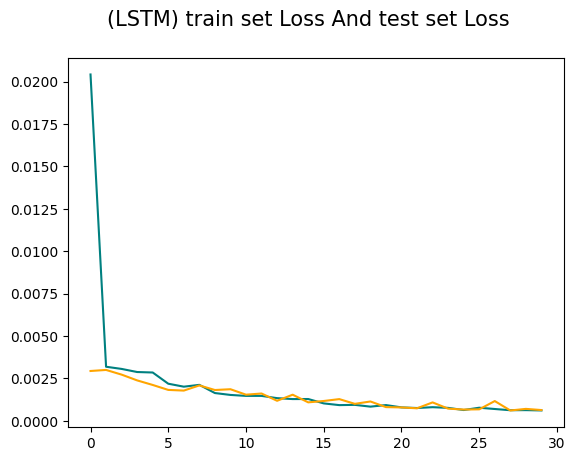

In [ ]:
fig=plt.figure()
epochs = range(len(LSTM_history.history['loss']))

plt.plot(epochs, LSTM_history.history['loss'],color = 'teal',label = 'loss')
plt.plot(epochs, LSTM_history.history['val_loss'],color = 'orange',label = 'val_loss')

fig.suptitle('(LSTM) train set Loss and test set Loss',fontsize = 15)
plt.show()

In [ ]:
# Train Data Set Preparation For Evaluation
# Cause the create dataset function will take 31 value to be x value in LSTM
Empty_set = np.zeros((time_step, 1))
train_data_with_overlap = np.concatenate((Empty_set, LSTM_train_data), axis = 0)
x_LSTM_train, y_LSTM_train = create_dataset(train_data_with_overlap, time_step)

# Scaling Back LSTM_train_pred And y_LSTM_train To Original Scale For RMSE
y_LSTM_train = scaler.inverse_transform(y_LSTM_train.reshape(-1, 1))  
LSTM_train_pred = LSTM_model.predict(x_LSTM_train)

# Inverse Transform Predictions
LSTM_train_pred = scaler.inverse_transform(LSTM_train_pred)

39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


In [ ]:
# Test Data Set Preparation For Evaluation
# Including The Last 31 Values From The Training Data Along With The Actual Test Data
test_data_with_overlap = np.concatenate((LSTM_train_data[-31:], LSTM_test_data), axis = 0)
x_LSTM_test, y_LSTM_test = create_dataset(test_data_with_overlap, time_step)

# Scaling Back LSTM_Predictions And y_LSTM_test To Original Scale For RMSE
y_LSTM_test = scaler.inverse_transform(y_LSTM_test.reshape(-1, 1))  
LSTM_predictions = LSTM_model.predict(x_LSTM_test)

# Inverse Transform Predictions
LSTM_predictions = scaler.inverse_transform(LSTM_predictions)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


Choosing the Right Metric
For general model accuracy: RMSE and MAE are commonly used.
For relative error: MAPE is useful when you want to understand errors in percentage terms.
For model fit: R-squared can give a high-level understanding of how well the model captures variance.

In [102]:
# Train Data Set Evaluation
print("Using train dataset to evaluate model:")
MSE = ms.mean_squared_error(y_LSTM_train,LSTM_train_pred)
print("MSE:",MSE)
RMSE = math.sqrt(ms.mean_squared_error(y_LSTM_train,LSTM_train_pred))
print("RMSE:", RMSE)
MAE = ms.mean_absolute_error(y_LSTM_train,LSTM_train_pred)
print('MAE:',MAE)
MAPE = np.mean(np.abs((y_LSTM_train-LSTM_train_pred) / y_LSTM_train)) * 100
print('MAPE:',MAPE)

EVS = ms.explained_variance_score(y_LSTM_train,LSTM_train_pred)
print("Explained variance regression score:", EVS)

R2 = ms.r2_score(y_LSTM_train,LSTM_train_pred)
print("R2-score:",R2)

Using train dataset to evaluate model:
MSE: 79.97982720449211
RMSE: 8.943144145349113
MAE: 6.246667252671281
MAPE: 5.733759304888175
Explained variance regression score: 0.9932075916348998
R2-score: 0.9932074331536263


In [103]:
# Test Data Set Evaluation
print("Using test dataset to evaluate model:")
MSE = ms.mean_squared_error(y_LSTM_test,LSTM_predictions)
print("MSE:",MSE)
RMSE = math.sqrt(ms.mean_squared_error(y_LSTM_test,LSTM_predictions))
print("RMSE:", RMSE)
MAE = ms.mean_absolute_error(y_LSTM_test,LSTM_predictions)
print('MAE:',MAE)
MAPE = np.mean(np.abs((y_LSTM_test-LSTM_predictions) / y_LSTM_test)) * 100
print('MAPE:',MAPE)

EVS = ms.explained_variance_score(y_LSTM_test,LSTM_predictions)
print("Explained variance regression score:", EVS)

R2 = ms.r2_score(y_LSTM_test,LSTM_predictions)
print("R2-score:",R2)

Using test dataset to evaluate model:
MSE: 85.4970188878162
RMSE: 9.246459802963304
MAE: 6.541749284224076
MAPE: 3.2062852860179
Explained variance regression score: 0.9096164176909427
R2-score: 0.9090266262816992


C:\Users\User\AppData\Local\Temp\ipykernel_30412\572339838.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Predictions']= LSTM_train_pred
C:\Users\User\AppData\Local\Temp\ipykernel_30412\572339838.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = LSTM_predictions


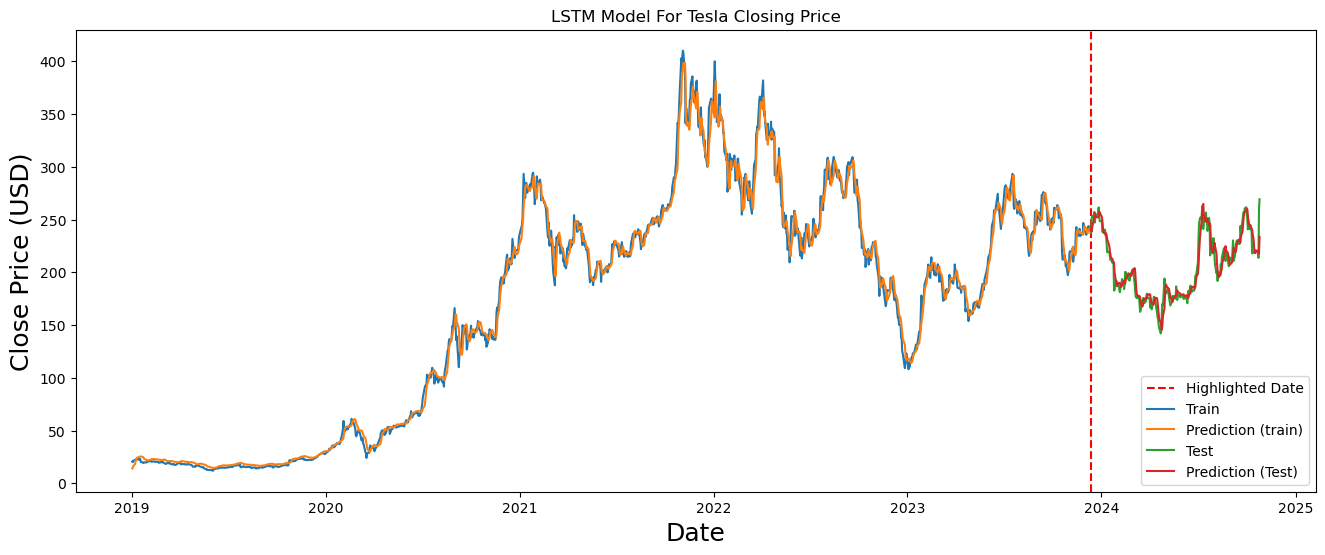

In [232]:
# Plot the data
train = LSTM_data[:LSTM_train_size]
train['Predictions']= LSTM_train_pred
valid = LSTM_data[LSTM_train_size:]
valid['Predictions'] = LSTM_predictions

# Visualize the data
plt.figure(figsize=(16,6))
plt.title('LSTM Model For Tesla Closing Price')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price (USD)', fontsize=18)

highlight_date = valid.index[0] 
plt.axvline(pd.to_datetime(highlight_date), color='r', linestyle='--', label='Highlighted Date')

plt.plot(train[['close','Predictions']])
plt.plot(valid[['close', 'Predictions']])
plt.legend(['Highlighted Date','Train','Prediction (train)', 'Test', 'Prediction (Test)'], loc='lower right')
plt.show()

# XGBoost

In [7]:
from xgboost import XGBRegressor
from xgboost import plot_importance
from sklearn.model_selection import train_test_split

In [8]:
XG_stk=stock[['time','close','Volume','RSI','MA 10','MA 20','MA 50','EMA 10','EMA 20','EMA 50','Trends','CCI','RVI']]

Can add more feature that are related to get more information to predict price

In [9]:
XG_stk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2926 entries, 0 to 2925
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    2926 non-null   object 
 1   close   2926 non-null   float64
 2   Volume  2926 non-null   float64
 3   RSI     2926 non-null   float64
 4   MA 10   2926 non-null   float64
 5   MA 20   2926 non-null   float64
 6   MA 50   2926 non-null   float64
 7   EMA 10  2926 non-null   float64
 8   EMA 20  2926 non-null   float64
 9   EMA 50  2926 non-null   float64
 10  Trends  2926 non-null   float64
 11  CCI     2926 non-null   float64
 12  RVI     2926 non-null   float64
dtypes: float64(12), object(1)
memory usage: 297.3+ KB


Take value from 2018 until now

In [10]:
XG_stk = XG_stk.iloc[yci[5]:]

In [11]:
XG_stk.shape

(1716, 13)

Other attribute is calculated by the historical value, but only the Volume is not, so i use the previous day volume to replace current day volume

In [12]:
XG_stk.head()

,time,close,Volume,RSI,MA 10,MA 20,MA 50,EMA 10,EMA 20,EMA 50,Trends,CCI,RVI
1210,2/1/2018,21.368645,0.064637,44.405880,21.546512,21.569378,21.247085,21.381369,21.451308,21.623131,44.039535,-33.012352,42.405958
1211,3/1/2018,21.149979,0.067435,32.001218,21.402379,21.609545,21.209952,21.339298,21.422610,21.604576,35.613012,-30.544936,36.074918
1212,4/1/2018,20.974646,0.157106,31.698919,21.292512,21.645945,21.180085,21.272998,21.379947,21.579873,27.569208,-77.144096,38.186797
1213,5/1/2018,21.105312,0.068587,34.217159,21.209846,21.657012,21.152406,21.242509,21.353791,21.561263,31.308241,-65.716890,38.980983
1214,8/1/2018,22.427311,0.155670,45.695768,21.241512,21.740912,21.166499,21.457928,21.456031,21.595226,73.684386,28.007381,47.524397


In [13]:
XG_stk.tail()

,time,close,Volume,RSI,MA 10,MA 20,MA 50,EMA 10,EMA 20,EMA 50,Trends,CCI,RVI
2921,21/10/2024,218.85,0.044851,22.952631,226.262,239.4415,227.7604,225.959271,230.898729,228.738762,18.220358,-100.566766,41.822316
2922,22/10/2024,217.97,0.040377,25.851610,223.609,237.6265,228.1700,224.506676,229.667422,228.316458,20.182932,-93.374400,40.815293
2923,23/10/2024,213.65,0.081889,27.585062,220.869,235.4580,228.2864,222.532735,228.141953,227.741303,17.249903,-91.972399,40.455920
2924,24/10/2024,260.48,0.218042,55.324596,223.040,235.7710,229.4684,229.432238,231.221767,229.025173,86.183438,88.350306,47.740236
2925,25/10/2024,269.19,0.170688,64.600494,228.179,236.2075,230.5694,236.660922,234.837789,230.600264,96.242587,127.483375,57.788220


In [14]:
XG_stk['Volume'] = XG_stk['Volume'].shift(+1)

# Display the DataFrame to confirm the changes
XG_stk.head()

,time,close,Volume,RSI,MA 10,MA 20,MA 50,EMA 10,EMA 20,EMA 50,Trends,CCI,RVI
1210,2/1/2018,21.368645,NaN,44.405880,21.546512,21.569378,21.247085,21.381369,21.451308,21.623131,44.039535,-33.012352,42.405958
1211,3/1/2018,21.149979,0.064637,32.001218,21.402379,21.609545,21.209952,21.339298,21.422610,21.604576,35.613012,-30.544936,36.074918
1212,4/1/2018,20.974646,0.067435,31.698919,21.292512,21.645945,21.180085,21.272998,21.379947,21.579873,27.569208,-77.144096,38.186797
1213,5/1/2018,21.105312,0.157106,34.217159,21.209846,21.657012,21.152406,21.242509,21.353791,21.561263,31.308241,-65.716890,38.980983
1214,8/1/2018,22.427311,0.068587,45.695768,21.241512,21.740912,21.166499,21.457928,21.456031,21.595226,73.684386,28.007381,47.524397


In [15]:
XG_stk.tail()

,time,close,Volume,RSI,MA 10,MA 20,MA 50,EMA 10,EMA 20,EMA 50,Trends,CCI,RVI
2921,21/10/2024,218.85,0.047367,22.952631,226.262,239.4415,227.7604,225.959271,230.898729,228.738762,18.220358,-100.566766,41.822316
2922,22/10/2024,217.97,0.044851,25.851610,223.609,237.6265,228.1700,224.506676,229.667422,228.316458,20.182932,-93.374400,40.815293
2923,23/10/2024,213.65,0.040377,27.585062,220.869,235.4580,228.2864,222.532735,228.141953,227.741303,17.249903,-91.972399,40.455920
2924,24/10/2024,260.48,0.081889,55.324596,223.040,235.7710,229.4684,229.432238,231.221767,229.025173,86.183438,88.350306,47.740236
2925,25/10/2024,269.19,0.218042,64.600494,228.179,236.2075,230.5694,236.660922,234.837789,230.600264,96.242587,127.483375,57.788220


In [16]:
# Drop rows with NaN values created by the shift at the end of the data
XG_stk = XG_stk.dropna().reset_index(drop=True)

In [17]:
XG_stk.head()

,time,close,Volume,RSI,MA 10,MA 20,MA 50,EMA 10,EMA 20,EMA 50,Trends,CCI,RVI
0,3/1/2018,21.149979,0.064637,32.001218,21.402379,21.609545,21.209952,21.339298,21.422610,21.604576,35.613012,-30.544936,36.074918
1,4/1/2018,20.974646,0.067435,31.698919,21.292512,21.645945,21.180085,21.272998,21.379947,21.579873,27.569208,-77.144096,38.186797
2,5/1/2018,21.105312,0.157106,34.217159,21.209846,21.657012,21.152406,21.242509,21.353791,21.561263,31.308241,-65.716890,38.980983
3,8/1/2018,22.427311,0.068587,45.695768,21.241512,21.740912,21.166499,21.457928,21.456031,21.595226,73.684386,28.007381,47.524397
4,9/1/2018,22.245978,0.155670,46.759259,21.298112,21.802778,21.176525,21.601210,21.531264,21.620745,65.574529,48.614576,49.311387


In [18]:
# Change the format of the time column, and set time to be index
XG_stk1 = XG_stk.copy()
XG_stk1.time = pd.to_datetime(XG_stk1.time, dayfirst=True)
XG_stk1.index = XG_stk1.time
XG_stk1 = XG_stk1.drop(['time'],axis=1)

In [19]:
XG_stk1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1715 entries, 2018-01-03 to 2024-10-25
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   close   1715 non-null   float64
 1   Volume  1715 non-null   float64
 2   RSI     1715 non-null   float64
 3   MA 10   1715 non-null   float64
 4   MA 20   1715 non-null   float64
 5   MA 50   1715 non-null   float64
 6   EMA 10  1715 non-null   float64
 7   EMA 20  1715 non-null   float64
 8   EMA 50  1715 non-null   float64
 9   Trends  1715 non-null   float64
 10  CCI     1715 non-null   float64
 11  RVI     1715 non-null   float64
dtypes: float64(12)
memory usage: 174.2 KB


In [20]:
# Specify test size and disable shuffling
XG_train_data, XG_test_data = train_test_split(XG_stk1, test_size = 0.20, shuffle = False)

Get the x and y based on train/test dataset

In [21]:
y_XG_train = XG_train_data['close'].copy()
X_XG_train = XG_train_data.drop(['close'],axis = 1)

y_XG_test = XG_test_data['close'].copy()
X_XG_test = XG_test_data.drop(['close'],axis = 1)

X_XG_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1372 entries, 2018-01-03 to 2023-06-15
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Volume  1372 non-null   float64
 1   RSI     1372 non-null   float64
 2   MA 10   1372 non-null   float64
 3   MA 20   1372 non-null   float64
 4   MA 50   1372 non-null   float64
 5   EMA 10  1372 non-null   float64
 6   EMA 20  1372 non-null   float64
 7   EMA 50  1372 non-null   float64
 8   Trends  1372 non-null   float64
 9   CCI     1372 non-null   float64
 10  RVI     1372 non-null   float64
dtypes: float64(11)
memory usage: 128.6 KB


In [22]:
y_XG_train.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 1372 entries, 2018-01-03 to 2023-06-15
Series name: close
Non-Null Count  Dtype  
--------------  -----  
1372 non-null   float64
dtypes: float64(1)
memory usage: 21.4 KB


In [23]:
# Train final model with the parameters on the training set
XG_model = XGBRegressor(n_estimators= 300,
                     learning_rate=0.1,
                     max_depth= 9,
                     gamma= 0.02,
                     objective='reg:squarederror', 
                     verbosity=0)
XG_model.fit(X_XG_train, y_XG_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0.02, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=9, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [24]:
# Train Data Evaluation
y_XG_train_pred = XG_model.predict(X_XG_train)

print("Using train dataset to evaluate model:")
MSE = ms.mean_squared_error(y_XG_train,y_XG_train_pred)
print("MSE:",MSE)
RMSE = math.sqrt(ms.mean_squared_error(y_XG_train,y_XG_train_pred))
print("RMSE:", RMSE)
MAE = ms.mean_absolute_error(y_XG_train,y_XG_train_pred)
print('MAE:',MAE)
MAPE = np.mean(np.abs(y_XG_train-y_XG_train_pred) /y_XG_train) * 100
print('MAPE:',MAPE)

EVS = ms.explained_variance_score(y_XG_train,y_XG_train_pred)
print("Explained variance regression score:", EVS)

R2 = ms.r2_score(y_XG_train,y_XG_train_pred)
print("R2-score:",R2)

Using train dataset to evaluate model:
MSE: 0.019262111604415686
RMSE: 0.13878800958445828
MAE: 0.09701851228101173
MAPE: 0.18015874606607504
Explained variance regression score: 0.9999985164475241
R2-score: 0.9999985164475224


In [25]:
# Test Data Evaluation
y_XG_prediction = XG_model.predict(X_XG_test)

print("Using test dataset to evaluate model:")
MSE = ms.mean_squared_error(y_XG_test,y_XG_prediction)
print("MSE:",MSE)
RMSE = math.sqrt(ms.mean_squared_error(y_XG_test,y_XG_prediction))
print("RMSE:", RMSE)
MAE = ms.mean_absolute_error(y_XG_test,y_XG_prediction)
print('MAE:',MAE)
MAPE = np.mean(np.abs(y_XG_test-y_XG_prediction) /y_XG_test) * 100
print('MAPE:',MAPE)

EVS = ms.explained_variance_score(y_XG_test,y_XG_prediction)
print("Explained variance regression score:", EVS)

R2 = ms.r2_score(y_XG_test,y_XG_prediction)
print("R2-score:",R2)

Using test dataset to evaluate model:
MSE: 36.21212376158764
RMSE: 6.017651016932407
MAE: 4.643445384745696
MAPE: 2.1395337839854216
Explained variance regression score: 0.9687691032212383
R2-score: 0.9687690780305831


<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

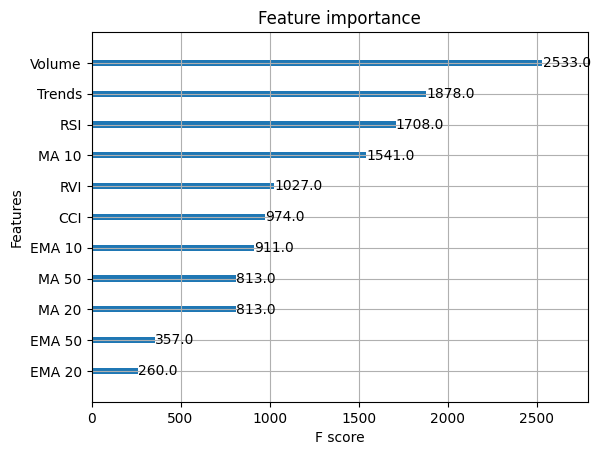

In [26]:
plot_importance(XG_model)

Modify the Dataframe to make it more suitable for plotting

In [112]:
XG_stk2=XG_stk1[['close']]
XG_train, XG_test = train_test_split(XG_stk2, test_size = 0.20, shuffle = False)

XG_test['Predictions'] = y_XG_prediction

XG_train['Predictions']= y_XG_train_pred

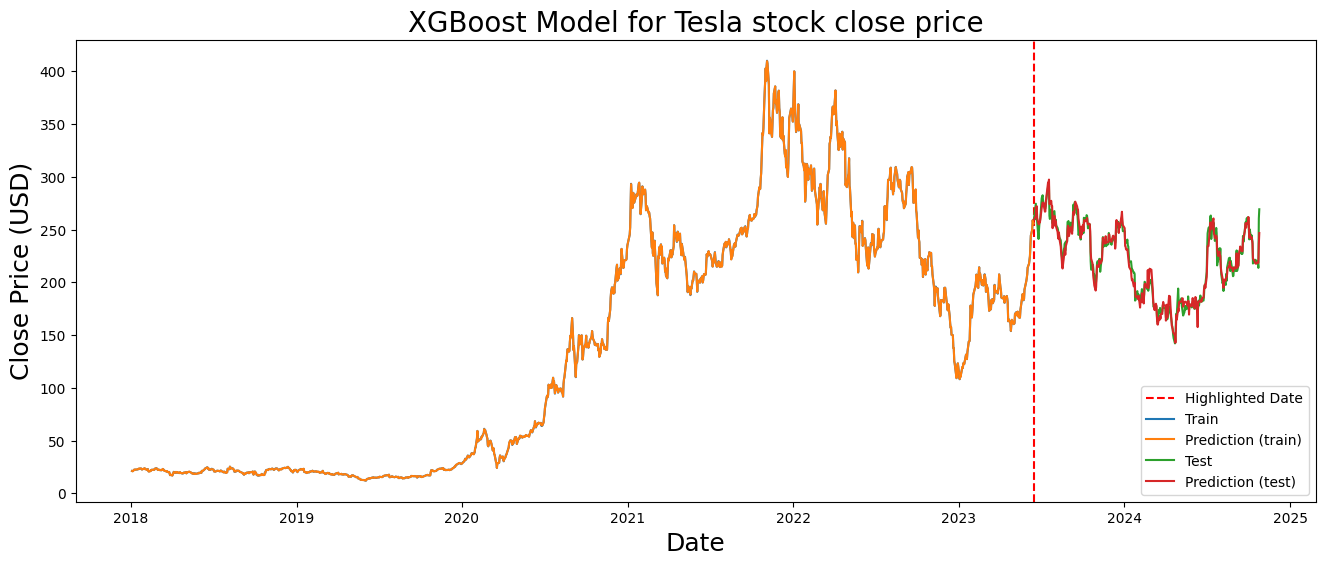

In [113]:
# Visualization Of Data
plt.figure(figsize=(16,6))
plt.title('XGBoost Model for Tesla stock close price',fontsize=20)
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price (USD)', fontsize=18)

highlight_date = XG_test.index[0]
plt.axvline(pd.to_datetime(highlight_date), color = 'r', linestyle = '--')

plt.plot(XG_train[['close','Predictions']])
plt.plot(XG_test[['close', 'Predictions']])
plt.legend(['Highlighted Date','Train','Prediction (train)', 'Test', 'Prediction (test)'], loc='lower right')
plt.show()